# Stage 4a — Generalised LoRA Fine-Tuning
## Model: `meta-llama/Llama-3.2-3B-Instruct` | Dataset: CB1 (6-Class Cyberbullying)
**Framework:** Generalised LoRA — Wf = W(I + UV) + AB  
**This stage:** Both multiplicative AND additive components active simultaneously  
**Seed:** 42 | **Split:** 75/25 stratified | **Primary metric:** Macro F1 | **Secondary:** MCC

---

## README — Before Step 1: Stage 4 Conceptual Position

Read this before running any code. It explains exactly what Stage 4 adds over Stages 2 and 3.

### Formula comparison across all four stages

| Aspect | Stage 2 — Standard LoRA | Stage 3 — Multiplicative LoRA | Stage 4 — Generalised LoRA |
|---|---|---|---|
| **Formula** | `Wf = W + AB` | `Wf = W(I + UV)` | `Wf = W(I + UV) + AB` |
| **L1 component** | I (identity — no multiplicative) | I + UV (square adapter) | I + UV (square adapter) |
| **L2 component** | AB (trainable) | 0 (absent) | AB (trainable) |
| **Initialisation** | B=0 → AB=0 at start | V=0 → UV=0 at start | B=0 AND V=0 → both zero at start |
| **Effect on rank** | rank(W+AB) ≤ rank(W) + r₂ | rank(W(I+UV)) = rank(W) if I+UV invertible | rank(Wf) ≤ rank(W) + r₂ — AB can push beyond rank(W) |
| **Eff. rank prediction** | Constant ✓ (Stage 2) | Constant for 3/5 models (Stage 3) | **Novel: AB may increase eff. rank above rank(W)** |
| **Trainable params** | 2·m·r₂ + 2·n·r₂ | 2·n·r₁ | 2·n·r₁ + 2·m·r₂ + 2·n·r₂ (both adapters) |
| **PEFT strategy** | LoraConfig + get_peft_model | PEFT shell + MultiplicativeLoRALayer | PEFT shell + GeneralisedLoRALayer (both) |

### Why Stage 4 is the primary research contribution

Stage 4 combines complementary adaptation mechanisms:
- **Multiplicative path** (UV): re-routes W's existing computation within its column space
- **Additive path** (AB): adds new directions — can recover or expand rank beyond rank(W)
- **Together**: neither path limits the other. If UV reduces rank, AB compensates (Proposition 2/Weyl bound)

The central hypothesis is that `Wf = W(I + UV) + AB` outperforms both Stage 2 (`W + AB`) and Stage 3 (`W(I+UV)`) on both CB1 and CB2.

### Effective rank — Stage 4 novel measurement

- Stage 2: `eff_rank(Wf) = eff_rank(W + AB)` — constant at rank(W) (Proposition 1 confirmed)
- Stage 3: `eff_rank(Wf) = eff_rank(W(I+UV))` — constant for 3/5 models; varies for Mistral and Phi-4
- **Stage 4: `eff_rank(Wf) = eff_rank(W(I+UV) + AB)`** — if AB contributes new singular directions, eff_rank(Wf) may EXCEED rank(W). This would empirically demonstrate Proposition 2 (Weyl bound) in action. Report and discuss in paper.

### Mistral r=16 instability — watch in Stage 4

Mistral CB1 r=16 collapsed in Stage 3 (F1=0.7616, stability=0.624). The AB additive component may stabilise this — if gradients through UV diverge, AB can compensate. Monitor loss at r=16 for Mistral closely. Either outcome is publishable:
- **Stabilises** → generalised LoRA is more robust than multiplicative alone
- **Collapses again** → Mistral r=16 instability is a confirmed architectural characteristic, independent of adaptation type

### Protocol (non-negotiable — carries from Stages 2 and 3)

- **Step 12:** r=16 (default). **Step 13:** RANK_SWEEP = [4, 8, 32] — r=16 NOT repeated, merged from Step 12
- CB1: MAX_LENGTH=256 | Batch=16 | lora_alpha = lora_rank | EVAL_STEPS=200
- Training time printed after every `trainer.train()` in seconds and hours
- `train_runtime_s` saved to CSV every run
- Stability plot: 2 panels only (loss + val metrics) — identical to Stages 2 and 3
- No EarlyStoppingCallback — removed (meaningless with 1 epoch)
- Stage 2 reference (Llama-3B r=16): F1=0.8938 | Eff.Rank=2030.73
- Stage 3 reference (Llama-3B r=16): F1=0.8918 | Eff.Rank=2030.39
- Stage 2 best overall (Gemma-2-9B r=32): **F1=0.9010** ← primary target to beat


---
## Step 1: Install Required Libraries

**Purpose**: Install all Python packages with pinned versions compatible with Colab's environment.

**Identical to Stage 3** — same pins, same rationale. Do not use `-U` (upgrade-all).

| Problem | Symptom | Fix |
|---|---|---|
| `numpy>=2.1` | `ImportError: cannot import name '_center'` at torch import | Pin `numpy<2.1` |
| `pandas>=3.0` | Breaks cudf, db-dtypes | Pin `pandas<3.0` |
| `torchvision` mismatch | `ImportError` during datasets formatting | Pin `torchvision==0.20.1` |

**After running this cell: Runtime → Restart Runtime, then run from Step 2 onwards.**  
Do NOT re-run Step 1 after restart.


In [1]:
# ── Install with pinned versions — compatible with Colab torch 2.5.x ───────────
# Do NOT use -U (upgrade-all) — it upgrades numpy/pandas/torchvision and breaks imports.
#
# transformers is pinned to <4.52 because >=4.52 requires torch>=2.6 (float8_e8m0fnu).
# Colab currently ships torch 2.5.x — using transformers>=4.52 causes:
#   AttributeError: module torch has no attribute float8_e8m0fnu
#   ModuleNotFoundError: Could not import module TrainingArguments
#
!pip install -q \
    "transformers>=4.47.0,<4.52.0" \
    "peft>=0.14.0" \
    "bitsandbytes>=0.45.0" \
    "accelerate>=1.2.0" \
    "datasets>=3.0.0" \
    "numpy<2.1" \
    "pandas<3.0" \
    "torchvision==0.20.1" \
    "scikit-learn" \
    tqdm matplotlib seaborn

print("✓ Installation complete.")
print()
print("=" * 60)
print("  ACTION REQUIRED: Restart the Colab runtime now.")
print("  Runtime → Restart Runtime  (or Ctrl+M .)")
print("  After restart: run from Step 2 onwards.")
print("  Do NOT re-run Step 1 after restart.")
print("=" * 60)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 140.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 116.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

---
## Step 2: Import Libraries and Initial Setup

**Purpose**: Import all modules, set random seeds, load HF token, mount Drive.  
**Identical to Stage 3** — only stage labels in print statements differ.  
`bitsandbytes.functional` is imported at top level (needed for 4-bit dequantisation in eff. rank).


In [2]:
import os
import random
import collections
import re
from typing import Dict, List

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    matthews_corrcoef,
)

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    TrainerCallback,
)
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model
# NOTE: LoraConfig + get_peft_model are used as a PEFT registration shell (same as Stage 3).
# Transformers Trainer (>=4.47) checks _is_peft_model(model) and rejects purely quantised models.
# We register first, then replace PEFT LoRA layers with GeneralisedLoRALayer.

import bitsandbytes.functional as bnb_F

from google.colab import drive, userdata

# ── Reproducibility ──────────────────────────────────────────────────────────
def set_all_seeds(seed: int = 42):
    """Fix all random seeds for fully reproducible training."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✓ All random seeds fixed to {seed}.")

set_all_seeds(42)

# ── HuggingFace token ────────────────────────────────────────────────────────
def load_hf_token() -> str:
    token = userdata.get('HF_TOKEN')
    if token is None:
        raise ValueError("HF_TOKEN not found. Add it via Colab Secrets (key icon in sidebar).")
    os.environ['HF_TOKEN'] = token
    print("✓ HuggingFace token loaded.")
    return token

HF_TOKEN = load_hf_token()

# ── Mount Google Drive ───────────────────────────────────────────────────────
drive.mount('/content/drive')
print("✓ Google Drive mounted.")

# ── GPU check ────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


✓ All random seeds fixed to 42.
✓ HuggingFace token loaded.
Mounted at /content/drive
✓ Google Drive mounted.
✓ Device: cuda
  GPU: NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB


---
## Step 3: Global Configuration

**Purpose**: All hyperparameters and settings in one place.  
**Changes from Stage 3:**
- `OUTPUT_DIR` updated to Stage 4 path
- Formula label updated to `Wf = W(I + UV) + AB`
- `RANK_SWEEP = [4, 8, 32]` — r=16 from Step 12, NOT repeated (same as Stage 3)
- Everything else **identical to Stage 3**


In [3]:
# ════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIGURATION — Stage 4a: Generalised LoRA | CB1 | Llama-3.2-3B
# ════════════════════════════════════════════════════════════════════════════

# ── Model ─────────────────────────────────────────────────────────────────────
MODEL_NAME   = "meta-llama/Llama-3.2-3B-Instruct"
NUM_LABELS   = 6
MAX_LENGTH   = 256

# ── LoRA (Generalised) ────────────────────────────────────────────────────────
LORA_RANK    = 16           # Default rank for Step 12 — same r used for BOTH UV and AB
LORA_ALPHA   = 16           # Always equals LORA_RANK → scaling = 1.0
LORA_DROPOUT = 0.05
TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj']

# Stage 4 rank sweep: r=16 already run in Step 12 — NOT repeated here
RANK_SWEEP   = [4, 8, 32]   # Step 13 only — r=16 merged from Step 12

# ── Training ──────────────────────────────────────────────────────────────────
NUM_EPOCHS          = 1     # Single epoch — protocol requirement
LEARNING_RATE       = 2e-4
TRAIN_BATCH_SIZE    = 16    # Confirmed safe for Llama-3B on A100 40GB
EVAL_BATCH_SIZE     = 32
WEIGHT_DECAY        = 0.01
EVAL_STEPS          = 200
LOGGING_STEPS       = 50
OUTPUT_DIR          = "/content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Llama3B"

# ── Dataset & Split ───────────────────────────────────────────────────────────
CB1_PATH             = "/content/drive/MyDrive/Datasets/cb1.csv"
TRAIN_RATIO          = 0.75
TEST_RATIO           = 0.25
VAL_FROM_TRAIN       = 0.10
SIMILARITY_THRESHOLD = 0.90
RANDOM_STATE         = 42

# ── Label mapping ─────────────────────────────────────────────────────────────
LABEL_MAPPING = {
    'not_cyberbullying':   0,
    'gender':              1,
    'religion':            2,
    'ethnicity':           3,
    'age':                 4,
    'other_cyberbullying': 5,
}
ID2LABEL     = {v: k for k, v in LABEL_MAPPING.items()}
TARGET_NAMES = list(LABEL_MAPPING.keys())

print("✓ Configuration loaded.")
print(f"  Stage    : 4a — Generalised LoRA")
print(f"  Formula  : Wf = W(I + UV) + AB   [L1 + L2 active simultaneously]")
print(f"  Model    : {MODEL_NAME}")
print(f"  LoRA rank: {LORA_RANK}  |  alpha: {LORA_ALPHA}  |  scaling: {LORA_ALPHA/LORA_RANK:.1f}")
print(f"  Epochs   : {NUM_EPOCHS}")
print(f"  Split    : {int(TRAIN_RATIO*100)}% train+val / {int(TEST_RATIO*100)}% test")
print(f"  Labels ({NUM_LABELS}): {TARGET_NAMES}")
print(f"  Rank sweep (Step 13): {RANK_SWEEP}  [r=16 from Step 12 — not repeated]")
print()
print(f"  Stage 2 reference (Llama-3B, r=16) : F1=0.8938 | MCC=0.8851 | Eff.Rank=2030.73")
print(f"  Stage 3 reference (Llama-3B, r=16) : F1=0.8918 | MCC=0.8831 | Eff.Rank=2030.39")
print(f"  Stage 2 best overall (Gemma-2-9B r=32): F1=0.9010 | MCC=0.8936  ← TARGET")
print(f"  Stage 1 ceiling (Phi-4 FS)           : F1=0.5757 | MCC=0.5614")


✓ Configuration loaded.
  Stage    : 4a — Generalised LoRA
  Formula  : Wf = W(I + UV) + AB   [L1 + L2 active simultaneously]
  Model    : meta-llama/Llama-3.2-3B-Instruct
  LoRA rank: 16  |  alpha: 16  |  scaling: 1.0
  Epochs   : 1
  Split    : 75% train+val / 25% test
  Labels (6): ['not_cyberbullying', 'gender', 'religion', 'ethnicity', 'age', 'other_cyberbullying']
  Rank sweep (Step 13): [4, 8, 32]  [r=16 from Step 12 — not repeated]

  Stage 2 reference (Llama-3B, r=16) : F1=0.8938 | MCC=0.8851 | Eff.Rank=2030.73
  Stage 3 reference (Llama-3B, r=16) : F1=0.8918 | MCC=0.8831 | Eff.Rank=2030.39
  Stage 2 best overall (Gemma-2-9B r=32): F1=0.9010 | MCC=0.8936  ← TARGET
  Stage 1 ceiling (Phi-4 FS)           : F1=0.5757 | MCC=0.5614


---
## Step 4: Text Preprocessing

**Purpose**: Define LLM-optimised preprocessing for raw tweet text.  
**Identical to Stages 2 and 3** — must be copied verbatim to guarantee the same
post-cleaning dataset and therefore the same 75/25 split (seeded at 42), making
cross-stage comparisons valid.


In [4]:
def preprocess_text_for_llm(text: str,
                             remove_hashtags: bool = False,
                             remove_emojis: bool = False) -> str:
    """LLM-optimised tweet preprocessing — identical to Stages 2 and 3."""
    if not isinstance(text, str):
        return ""

    text = re.sub(r'\bRT\s+@\w+:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'http\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'@\w+', '[USER]', text)
    if remove_hashtags:
        text = re.sub(r'#(\w+)', r'\1', text)
    if remove_emojis:
        text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'([!?.])\1+', r'\1', text)
    if len(text.split()) < 3:
        return ""
    return text

# ── Quick sanity check ───────────────────────────────────────────────────────
test_tweet = "RT @user123: Check this out http://example.com !!! @someone is so dumb"
print("Before:", test_tweet)
print("After: ", preprocess_text_for_llm(test_tweet))
print("\n✓ Preprocessing function defined.")


Before: RT @user123: Check this out http://example.com !!! @someone is so dumb
After:  Check this out [URL] ! [USER] is so dumb

✓ Preprocessing function defined.


---
## Step 5: Load and Clean the CB1 Dataset

**Purpose**: Load `cb1.csv`, apply all cleaning steps.  
**Columns**: `tweet_text` | `cyberbullying_type`  
**Identical to Stages 2 and 3** — same pipeline guarantees same post-cleaning dataset,
required so seed=42 produces the same train/test sets across all stages.


In [5]:
print("═" * 60)
print("CB1 DATASET LOADING & CLEANING")
print("═" * 60)

df = pd.read_csv(CB1_PATH)
print(f"\n[1] Raw dataset loaded: {len(df):,} samples")

df = df.rename(columns={'tweet_text': 'text', 'cyberbullying_type': 'label'})
print(f"[2] Columns renamed: {df.columns.tolist()}")

corrupt_mask = df['text'].astype(str).str.strip().isin(
    ['#NAME?', '#REF!', '#VALUE!', '#N/A', 'nan', ''])
n_corrupt = corrupt_mask.sum()
df = df[~corrupt_mask].reset_index(drop=True)
print(f"[3] Removed {n_corrupt} corrupt rows → {len(df):,} remaining")

df['text'] = df['text'].apply(preprocess_text_for_llm)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"[4] After preprocessing: {len(df):,} remaining")

text_label_counts = df.groupby('text')['label'].nunique()
conflicting_texts = text_label_counts[text_label_counts > 1].index
n_conflicting     = df['text'].isin(conflicting_texts).sum()
df = df[~df['text'].isin(conflicting_texts)].reset_index(drop=True)
print(f"[5] Removed {n_conflicting:,} annotation-conflict rows → {len(df):,} remaining")

before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f"[6] Removed {before - len(df):,} exact duplicates → {len(df):,} remaining")

before = len(df)
df = df[df['text'].str.split().str.len() >= 3].reset_index(drop=True)
print(f"[7] Removed {before - len(df):,} short texts → {len(df):,} remaining")

unknown_labels = set(df['label'].unique()) - set(LABEL_MAPPING.keys())
assert len(unknown_labels) == 0, f"Unknown labels: {unknown_labels}"

print("\n" + "═" * 60)
print("FINAL CB1 CLASS DISTRIBUTION")
print("═" * 60)
counts = df['label'].value_counts()
for label, count in counts.items():
    print(f"  {label:<25} {count:>6}  ({count/len(df)*100:.1f}%)")
print(f"  {'TOTAL':<25} {len(df):>6}")
imbalance = counts.max() / counts.min()
print(f"\n  Imbalance ratio : {imbalance:.2f}×")
print("  Primary metric  : Macro F1  |  Secondary: MCC")


════════════════════════════════════════════════════════════
CB1 DATASET LOADING & CLEANING
════════════════════════════════════════════════════════════

[1] Raw dataset loaded: 47,692 samples
[2] Columns renamed: ['text', 'label']
[3] Removed 0 corrupt rows → 47,692 remaining
[4] After preprocessing: 46,942 remaining
[5] Removed 3,250 annotation-conflict rows → 43,692 remaining
[6] Removed 358 exact duplicates → 43,334 remaining
[7] Removed 0 short texts → 43,334 remaining

════════════════════════════════════════════════════════════
FINAL CB1 CLASS DISTRIBUTION
════════════════════════════════════════════════════════════
  religion                    7979  (18.4%)
  age                         7972  (18.4%)
  ethnicity                   7920  (18.3%)
  gender                      7509  (17.3%)
  not_cyberbullying           6130  (14.1%)
  other_cyberbullying         5824  (13.4%)
  TOTAL                      43334

  Imbalance ratio : 1.37×
  Primary metric  : Macro F1  |  Secondary:

---
## Step 6: Stratified 75/25 Split with Near-Duplicate Check

**Purpose**: Split dataset into train / val / test.  
**Identical to Stages 2 and 3** — same split protocol with seed=42 guarantees the exact
same test set across all stages, making cross-stage F1 comparisons valid.


In [6]:
print("═" * 60)
print("DATASET SPLITTING — Protocol: 75% train / 25% test")
print("═" * 60)

# ── Step 6a: Primary stratified split ────────────────────────────────────────
train_val_df, test_df = train_test_split(
    df,
    test_size=TEST_RATIO,
    random_state=RANDOM_STATE,
    stratify=df['label']
)
print(f"\n[1] Primary split → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")
print(f"    ({len(train_val_df)/len(df)*100:.1f}% / {len(test_df)/len(df)*100:.1f}%)")

# ── Step 6b: Near-duplicate leakage check ────────────────────────────────────
print(f"\n[2] Near-duplicate check (threshold: {SIMILARITY_THRESHOLD})...")

all_texts    = list(train_val_df['text'].values) + list(test_df['text'].values)
vectorizer   = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(all_texts)
train_vecs   = tfidf_matrix[:len(train_val_df)]
test_vecs    = tfidf_matrix[len(train_val_df):]

leaked_indices = []
batch_size     = 500
for start in range(0, len(test_df), batch_size):
    end         = min(start + batch_size, len(test_df))
    batch_sims  = cosine_similarity(test_vecs[start:end], train_vecs)
    max_sims    = batch_sims.max(axis=1)
    leaked_mask = max_sims >= SIMILARITY_THRESHOLD
    leaked_indices.extend(test_df.index[start:end][leaked_mask].tolist())

print(f"    Found {len(leaked_indices)} near-duplicate test samples")

if leaked_indices:
    leaked_samples = test_df.loc[leaked_indices]
    test_df        = test_df.drop(leaked_indices).reset_index(drop=True)
    train_val_df   = pd.concat([train_val_df, leaked_samples], ignore_index=True)
    print(f"    Moved to train+val → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")
else:
    train_val_df = train_val_df.reset_index(drop=True)
    test_df      = test_df.reset_index(drop=True)
    print("    ✓ No near-duplicates found.")

# ── Step 6c: Data leakage assertion ──────────────────────────────────────────
overlap = set(train_val_df['text'].tolist()).intersection(set(test_df['text'].tolist()))
assert len(overlap) == 0, f"DATA LEAKAGE DETECTED: {len(overlap)} overlapping samples!"
print("\n    ✓ Data leakage assertion passed — zero train/test overlap.")

# ── Step 6d: Carve validation set from train portion ─────────────────────────
train_df, val_df = train_test_split(
    train_val_df,
    test_size=VAL_FROM_TRAIN,
    random_state=RANDOM_STATE,
    stratify=train_val_df['label']
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"\n[3] Validation carved → Train: {len(train_df):,} | Val: {len(val_df):,}")

# ── Step 6e: Final statistics ─────────────────────────────────────────────────
print("\n" + "═" * 60)
print("FINAL SPLIT STATISTICS")
print("═" * 60)
for name, split_df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    pct = len(split_df) / len(df) * 100
    print(f"\n{name} ({len(split_df):,} samples, {pct:.1f}% of total):")
    for label, count in split_df['label'].value_counts().sort_index().items():
        print(f"  {label:<25} {count:>5}  ({count/len(split_df)*100:.1f}%)")

print(f"\n  ✓ Protocol check: test = {len(test_df)/len(df)*100:.1f}% (target: 25.0%)")


════════════════════════════════════════════════════════════
DATASET SPLITTING — Protocol: 75% train / 25% test
════════════════════════════════════════════════════════════

[1] Primary split → Train+Val: 32,500 | Test: 10,834
    (75.0% / 25.0%)

[2] Near-duplicate check (threshold: 0.9)...
    Found 504 near-duplicate test samples
    Moved to train+val → Train+Val: 33,004 | Test: 10,330

    ✓ Data leakage assertion passed — zero train/test overlap.

[3] Validation carved → Train: 29,703 | Val: 3,301

════════════════════════════════════════════════════════════
FINAL SPLIT STATISTICS
════════════════════════════════════════════════════════════

Train (29,703 samples, 68.5% of total):
  age                        5420  (18.2%)
  ethnicity                  5497  (18.5%)
  gender                     5149  (17.3%)
  not_cyberbullying          4235  (14.3%)
  other_cyberbullying        3995  (13.4%)
  religion                   5407  (18.2%)

Validation (3,301 samples, 7.6% of total):
  

---
## Step 7: Helper Functions — Class Weights

**Purpose**: Compute inverse-frequency class weights for the loss function.  
**Identical to Stage 3** — same function, same call site.


In [7]:
def get_class_weights(df: pd.DataFrame, label_col: str = 'label') -> List[float]:
    """Compute inverse-frequency class weights from training labels."""
    counts    = df[label_col].value_counts()
    total     = len(df)
    n_classes = len(LABEL_MAPPING)
    weights   = [total / (n_classes * counts.get(ID2LABEL[i], 1)) for i in range(n_classes)]
    weights_norm = [w / sum(weights) * n_classes for w in weights]
    print("Class weights (inverse-frequency, normalised):")
    for i, (cls, w) in enumerate(zip(TARGET_NAMES, weights_norm)):
        print(f"  [{i}] {cls:<25} {w:.4f}")
    return weights_norm

print("✓ get_class_weights() defined.")


✓ get_class_weights() defined.


---
## Step 8: Effective Rank Computation — Generalised LoRA

**Purpose**: Compute effective rank of the full adapted weight **Wf = W(I + UV) + AB**.

**Stage 4 formula decomposition:**  
`Wf = W(I + UV) + AB = W + W·UV + AB`

So in matrix form: `Wf = W + W@(UV) + A@B`

**What changes from Stage 3:**  
- Stage 3: SVD on `Wf = W + W@(UV)`  
- Stage 4: SVD on `Wf = W + W@(UV) + A@B` — the AB additive term is included

**Novel measurement for Stage 4:**  
If `eff_rank(Wf) > rank(W)`, the AB term has added new singular directions beyond W's column space.  
This empirically demonstrates Proposition 2 (Weyl bound): `rank(W(I+UV) + AB) ≤ rank(W(I+UV)) + rank(AB)`.  
Report the range and mean across ranks in the paper.

**What stays identical:**  
- W dequantised via `bnb_F.dequantize_4bit()` (same Bug1 fix from Stage 2)  
- SVD threshold: `threshold_ratio = 1e-3` of max singular value  
- Reports `avg_eff_rank_Wf` (full matrix), `avg_eff_rank_UV` (mult. adapter, reference), `avg_eff_rank_AB` (add. adapter, reference)  
- Measured on target layers only (`q_proj`, `k_proj`, `v_proj`, `o_proj`)


In [8]:
def calculate_effective_rank_generalised(model: nn.Module,
                                           threshold_ratio: float = 1e-3) -> Dict[str, float]:
    """
    Compute effective rank of Wf = W(I + UV) + AB = W + W@(UV) + A@B.

    Walks model for GeneralisedLoRALayer instances.
    Reconstructs Wf = W + W@(UV) + A@B by dequantising W from 4-bit NF4.
    SVD threshold: 0.1% of max singular value (consistent across all stages).

    Returns:
      avg_eff_rank_Wf  — full adapted weight (primary, report in paper)
      avg_eff_rank_UV  — multiplicative adapter alone (reference)
      avg_eff_rank_AB  — additive adapter alone (reference)
      layer_count      — number of GeneralisedLoRALayer layers measured
      per_layer_ranks  — per-layer breakdown for debugging
    """
    full_ranks = []
    uv_ranks   = []
    ab_ranks   = []
    per_layer  = []
    skipped    = 0

    for name, module in model.named_modules():
        if not isinstance(module, GeneralisedLoRALayer):
            continue
        try:
            # ── Reconstruct adapter matrices ──────────────────────────────────
            U  = module.lora_U.data.float()    # (n × r)
            V  = module.lora_V.data.float()    # (r × n)
            A  = module.lora_A.data.float()    # (m × r)
            B  = module.lora_B.data.float()    # (r × n)

            UV = U @ V     # (n × n)
            AB = A @ B     # (m × n)

            # ── Eff. rank of adapters alone (reference) ───────────────────────
            S_uv = torch.linalg.svdvals(UV)
            r_uv = int((S_uv > threshold_ratio * S_uv[0]).sum()) if S_uv[0] > 0 else 0
            uv_ranks.append(r_uv)

            S_ab = torch.linalg.svdvals(AB)
            r_ab = int((S_ab > threshold_ratio * S_ab[0]).sum()) if S_ab[0] > 0 else 0
            ab_ranks.append(r_ab)

            # ── Dequantise W from 4-bit NF4 ───────────────────────────────────
            weight_obj = module.inner.weight
            if hasattr(weight_obj, 'quant_state'):
                try:
                    W = bnb_F.dequantize_4bit(weight_obj.data, weight_obj.quant_state).float()
                except Exception:
                    skipped += 1
                    continue
            else:
                W = weight_obj.data.float()

            # Handle transpose if needed (weight stored as (out, in))
            if W.shape[1] != UV.shape[0]:
                if W.T.shape[1] == UV.shape[0]:
                    W = W.T.contiguous()
                else:
                    skipped += 1
                    continue

            # ── Full adapted weight: Wf = W + W@(UV) + A@B ───────────────────
            # W@(UV): multiplicative path — W re-routes through UV  (m×n)
            # A@B:    additive path — adds new directions            (m×n)
            W_UV = W @ UV              # (m × n)
            Wf   = W + W_UV + AB       # (m × n)

            S_Wf = torch.linalg.svdvals(Wf)
            r_Wf = int((S_Wf > threshold_ratio * S_Wf[0]).sum()) if S_Wf[0] > 0 else 0

            full_ranks.append(r_Wf)
            per_layer.append({
                'layer': name, 'rank_Wf': r_Wf, 'rank_UV': r_uv, 'rank_AB': r_ab
            })

        except Exception:
            skipped += 1
            continue

    if skipped > 0:
        print(f"  ℹ {skipped} layers skipped during eff. rank computation")
    if not full_ranks:
        print("  ⚠ No GeneralisedLoRALayer found — check model structure")

    return {
        "avg_eff_rank_Wf": float(np.mean(full_ranks)) if full_ranks else 0.0,
        "avg_eff_rank_UV": float(np.mean(uv_ranks))   if uv_ranks   else 0.0,
        "avg_eff_rank_AB": float(np.mean(ab_ranks))   if ab_ranks   else 0.0,
        "layer_count":     len(full_ranks),
        "per_layer_ranks": per_layer,
    }

print("✓ calculate_effective_rank_generalised() defined.")
print("  SVD on Wf = W + W@(UV) + A@B  — full Generalised LoRA matrix.")
print("  Stage 2 ref : SVD on W + A@B")
print("  Stage 3 ref : SVD on W + W@(UV)")
print("  Stage 4 (this): SVD on W + W@(UV) + A@B  ← novel: AB may push rank above rank(W)")


✓ calculate_effective_rank_generalised() defined.
  SVD on Wf = W + W@(UV) + A@B  — full Generalised LoRA matrix.
  Stage 2 ref : SVD on W + A@B
  Stage 3 ref : SVD on W + W@(UV)
  Stage 4 (this): SVD on W + W@(UV) + A@B  ← novel: AB may push rank above rank(W)


---
## Step 9: Evaluation Metrics

**Purpose**: Define all metric functions used during training and final evaluation.  
**Identical to Stages 2 and 3** — `compute_metrics()`, `evaluate_dataset()`, and `make_predictions()`
copied verbatim. Primary metric: Macro F1. Secondary: MCC.


In [9]:
def compute_metrics(eval_pred) -> Dict[str, float]:
    """Called by the Trainer at every eval_steps."""
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=1)
    accuracy  = accuracy_score(labels, predictions)
    _, _, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0)
    mcc = matthews_corrcoef(labels, predictions)
    return {"accuracy": accuracy, "f1": f1, "mcc": mcc}


def evaluate_dataset(y_true: List[int],
                     y_pred: List[int],
                     dataset_name: str) -> Dict[str, float]:
    """Full evaluation report: per-class F1, MCC, confusion matrices."""
    print(f"\n{'═'*65}")
    print(f"FINAL EVALUATION — {dataset_name}")
    print(f"{'═'*65}")

    accuracy     = accuracy_score(y_true, y_pred)
    macro_f1     = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    weighted_f1  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    bal_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc          = matthews_corrcoef(y_true, y_pred)

    print(f"  Accuracy          : {accuracy:.4f}")
    print(f"  Macro F1          : {macro_f1:.4f}  ← PRIMARY METRIC")
    print(f"  Weighted F1       : {weighted_f1:.4f}")
    print(f"  Balanced Accuracy : {bal_accuracy:.4f}")
    print(f"  MCC               : {mcc:.4f}  ← SECONDARY METRIC")

    print(f"\n  Classification Report:")
    report = classification_report(
        y_true, y_pred,
        labels=list(range(NUM_LABELS)),
        target_names=TARGET_NAMES,
        zero_division=0, digits=4
    )
    print(report)

    cm      = confusion_matrix(y_true, y_pred, labels=list(range(NUM_LABELS)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
    axes[0].set_title(f'Confusion Matrix (Counts)\n{dataset_name}', fontsize=12)
    axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')
    axes[0].tick_params(axis='x', rotation=45)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, vmin=0, vmax=1)
    axes[1].set_title(f'Confusion Matrix (Normalised)\n{dataset_name}', fontsize=12)
    axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_{dataset_name.replace(' ','_')}.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'accuracy': accuracy, 'macro_f1': macro_f1,
        'weighted_f1': weighted_f1, 'balanced_accuracy': bal_accuracy, 'mcc': mcc,
    }


def make_predictions(model, df_test, tokenizer, batch_size=32):
    """Run batched inference on test DataFrame. Returns df with 'predictions' column."""
    model.eval()
    all_preds = []
    texts     = df_test['text'].tolist()

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        enc = tokenizer(
            batch_texts, padding='max_length', truncation=True,
            max_length=MAX_LENGTH, return_tensors='pt'
        ).to(model.device)
        with torch.no_grad():
            logits = model(**enc).logits
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        all_preds.extend(preds.tolist())

    df_out = df_test.copy()
    df_out['predictions'] = [ID2LABEL[p] if isinstance(df_test['label'].iloc[0], str)
                             else p for p in all_preds]
    if isinstance(df_test['label'].iloc[0], str):
        df_out['label']       = df_out['label'].map(LABEL_MAPPING)
        df_out['predictions'] = df_out['predictions'].map(LABEL_MAPPING)
    return df_out


print("✓ compute_metrics(), evaluate_dataset(), make_predictions() defined.")
print("  Primary metric  : Macro F1  |  Secondary : MCC")


✓ compute_metrics(), evaluate_dataset(), make_predictions() defined.
  Primary metric  : Macro F1  |  Secondary : MCC


---
## Step 10: Training Stability System + Custom Trainer

**Purpose**: StabilityCallback (2-panel, single-epoch protocol) + class-weighted CustomTrainer.  
**Identical to Stages 2 and 3** — must be identical across stages so the cross-stage
comparison in Step 14 is valid. `plot_cross_stage_stability()` is now fully populated
with Stage 2, 3, and 4 labels — run it after this stage completes.


In [10]:
import matplotlib.gridspec as gridspec

class StabilityCallback(TrainerCallback):
    """
    2-dimension stability tracking (single-epoch protocol).
    Dimension 1 — Loss stability   : std dev & CV across training steps
    Dimension 2 — Metric stability : std dev of val F1 & MCC across eval checkpoints
    Panels 3 & 4 (grad norm / per-epoch) omitted — uninformative with 1 epoch.
    """
    def __init__(self):
        self.train_losses = []
        self.val_metrics  = collections.defaultdict(list)
        self.val_steps    = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or state.global_step == 0:
            return
        if 'loss' in logs:
            self.train_losses.append((state.global_step, float(logs['loss'])))

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics:
            return
        self.val_steps.append(state.global_step)
        for key, value in metrics.items():
            self.val_metrics[key.replace('eval_', '')].append(float(value))

    def get_stability_report(self) -> Dict:
        report = {}
        if self.train_losses:
            arr = np.array([l for (_, l) in self.train_losses])
            report['loss_mean_overall'] = float(np.mean(arr))
            report['loss_std_overall']  = float(np.std(arr))
            report['loss_cv_overall']   = float(np.std(arr) / np.mean(arr)) if np.mean(arr) > 0 else 0.0
        for metric, values in self.val_metrics.items():
            if len(values) > 1:
                arr = np.array(values)
                report[f'val_{metric}_std']   = float(np.std(arr))
                report[f'val_{metric}_range'] = float(arr.max() - arr.min())
                report[f'val_{metric}_best']  = float(arr.max())
                report[f'val_{metric}_final'] = float(arr[-1])
        loss_cv = report.get('loss_cv_overall', 0.0)
        f1_std  = report.get('val_f1_std', 0.0)
        report['stability_score'] = round((loss_cv * 0.5) + (f1_std * 0.5), 6)
        return report

    def plot_stability_curves(self, stage_label: str = 'Stage 4', save_path: str = None):
        """2-panel: Training loss curve + Validation F1 & MCC."""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        if self.train_losses:
            steps  = [s for (s, _) in self.train_losses]
            losses = [l for (_, l) in self.train_losses]
            ax1.plot(steps, losses, color='steelblue', linewidth=0.7, alpha=0.5, label='Step loss')
            window = min(20, len(losses))
            if len(losses) >= window:
                roll = np.convolve(losses, np.ones(window)/window, mode='valid')
                ax1.plot(steps[window-1:], roll, color='navy', linewidth=2.2,
                         label=f'Rolling mean (w={window})')
            ax1.set_title(f'{stage_label}\nTraining Loss Curve', fontsize=12)
            ax1.set_xlabel('Global Step'); ax1.set_ylabel('Cross-Entropy Loss')
            ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
        else:
            ax1.text(0.5, 0.5, 'No training loss data collected', ha='center', va='center')

        if self.val_steps:
            ax2_r = ax2.twinx() if 'mcc' in self.val_metrics else None
            if 'f1' in self.val_metrics:
                f1_vals = self.val_metrics['f1']
                ax2.plot(self.val_steps, f1_vals, 'o-', color='forestgreen',
                         linewidth=2, markersize=5, label='Macro F1')
                f1_mean = float(np.mean(f1_vals)); f1_std = float(np.std(f1_vals))
                ax2.axhline(f1_mean, color='forestgreen', linestyle=':', linewidth=1.2, alpha=0.6)
                ax2.fill_between(self.val_steps,
                                 [f1_mean - f1_std]*len(self.val_steps),
                                 [f1_mean + f1_std]*len(self.val_steps),
                                 color='forestgreen', alpha=0.10, label=f'±1 std (={f1_std:.4f})')
                ax2.set_ylabel('Macro F1', color='forestgreen', fontsize=10)
                ax2.tick_params(axis='y', labelcolor='forestgreen')
            if ax2_r and 'mcc' in self.val_metrics:
                mcc_vals = self.val_metrics['mcc']
                ax2_r.plot(self.val_steps, mcc_vals, 's--', color='darkorange',
                           linewidth=1.5, markersize=4, label='MCC', alpha=0.8)
                ax2_r.set_ylabel('MCC', color='darkorange', fontsize=10)
                ax2_r.tick_params(axis='y', labelcolor='darkorange')
            lines1, labels1 = ax2.get_legend_handles_labels()
            lines2, labels2 = (ax2_r.get_legend_handles_labels() if ax2_r else ([], []))
            ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
            ax2.set_title(f'{stage_label}\nValidation Metrics (F1 & MCC)', fontsize=12)
            ax2.set_xlabel('Global Step')
            ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, 'No validation data collected', ha='center', va='center')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"✓ Stability plot saved → {save_path}")
        plt.show()


def plot_cross_stage_stability(stage_reports: Dict[str, Dict], save_path: str = None):
    """
    4-panel cross-stage stability comparison.
    Call after all stages complete with their stability reports.
    Panel 1: Loss Std Dev | Panel 2: Loss CV | Panel 3: Val F1 Std | Panel 4: Stability Score
    """
    stages = list(stage_reports.keys())
    colors = ['#2E75B6', '#F4A261', '#1B998B', '#E63946'][:len(stages)]

    metrics_to_plot = [
        ('loss_std_overall', 'Loss Std Dev (overall)', 'lower = more stable'),
        ('loss_cv_overall',  'Loss CV (overall)',      'lower = more stable'),
        ('val_f1_std',       'Val F1 Std Dev',         'lower = more stable'),
        ('stability_score',  'Composite Stability Score', 'lower = more stable'),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    for ax, (key, title, subtitle) in zip(axes, metrics_to_plot):
        vals = [stage_reports[s].get(key, 0.0) for s in stages]
        bars = ax.bar(range(len(stages)), vals, color=colors, alpha=0.85,
                      edgecolor='white', linewidth=1.5, width=0.5)
        for i, v in enumerate(vals):
            ax.text(i, v + max(vals)*0.02, f'{v:.4f}', ha='center', va='bottom',
                    fontsize=9, fontweight='bold')
        if key == 'stability_score':
            ax.axhline(0.05,  color='green',  linestyle='--', linewidth=1.2, label='Very stable (< 0.05)')
            ax.axhline(0.15,  color='orange', linestyle='--', linewidth=1.2, label='Acceptable (< 0.15)')
            ax.legend(fontsize=8)
        ax.set_xticks(range(len(stages)))
        ax.set_xticklabels(stages, fontsize=9)
        ax.set_title(f'{title}\n({subtitle})', fontsize=11)
        ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle(
        'Cross-Stage Stability Comparison\n'
        'CB1 (6-Class) | meta-llama/Llama-3.2-3B-Instruct\n'
        'Stage 2: Wf=W+AB  |  Stage 3: Wf=W(I+UV)  |  Stage 4: Wf=W(I+UV)+AB',
        fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Cross-stage stability plot saved → {save_path}")
    plt.show()


class CustomTrainer(Trainer):
    """Trainer with inverse-frequency class-weighted cross-entropy loss."""
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        if class_weights is not None:
            self.class_weights = torch.tensor(class_weights, dtype=torch.float32)
        else:
            self.class_weights = None

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        if self.class_weights is not None:
            weights = self.class_weights.to(logits.device)
            loss_fn = nn.CrossEntropyLoss(weight=weights)
        else:
            loss_fn = nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


print("✓ StabilityCallback, plot_cross_stage_stability(), CustomTrainer defined.")
print("  Stability: 2-panel (loss curve + val metrics) — protocol-compliant.")
print("  plot_cross_stage_stability(): ready for final 3-stage comparison in Step 14.")


✓ StabilityCallback, plot_cross_stage_stability(), CustomTrainer defined.
  Stability: 2-panel (loss curve + val metrics) — protocol-compliant.
  plot_cross_stage_stability(): ready for final 3-stage comparison in Step 14.


---
## Step 11: Generalised LoRA Adapter + Training Function

**Purpose**: Define `GeneralisedLoRALayer` and `run_generalised_lora()`.  
**This is the only step that materially differs from Stages 2 and 3.**

### GeneralisedLoRALayer

Combines multiplicative (UV) and additive (AB) adapters in a single layer:

```
Forward: y = Wf · x
       = [W(I + UV) + AB] · x
       = W·x  +  W·(UV·x)  +  A·(B·x)
         base    mult. path    add. path
```

**Parameters:**
- `U ∈ ℝⁿˣʳ` — small Gaussian init (std=0.01)
- `V ∈ ℝʳˣⁿ` — zero init → UV=0 at start → multiplicative path inactive
- `A ∈ ℝᵐˣʳ` — small Gaussian init (std=0.01)  
- `B ∈ ℝʳˣⁿ` — zero init → AB=0 at start → additive path inactive

Both paths start at zero, so `Wf = W` at initialisation — identical to Stages 2 and 3.  
Both paths learn simultaneously during training.

**Scaling**: `alpha / rank = 1.0` applied to both adapter paths.

### PEFT shell strategy (identical to Stage 3)

1. Register model as PEFT via `get_peft_model()` — satisfies Trainer's `_is_peft_model()` check
2. Replace every PEFT LoraLayer with `GeneralisedLoRALayer` — custom dual adapter overwrites additive ones
3. Net result: Trainer sees valid PEFT model; all computation uses `Wf = W(I+UV) + AB`

### Trainable parameter count

At rank r: `2·n·r` (UV) + `2·m·r` (AB) where n=in_features, m=out_features  
For Llama-3B q/k/v/o at r=16: ~29.4M parameters (compare: S2=9.2M additive only, S3=20.2M mult. only)


In [11]:
import bitsandbytes as bnb

# ════════════════════════════════════════════════════════════════════════════
# GeneralisedLoRALayer — custom adapter for Wf = W(I + UV) + AB
# ════════════════════════════════════════════════════════════════════════════

class GeneralisedLoRALayer(nn.Module):
    """
    Wraps a frozen 4-bit linear layer with a generalised LoRA adapter.

    Formula: Wf = W(I + UV) + AB
    Forward: y = W·x + W·(U·(V·x)) + A·(B·x)
             base    mult. path       add. path

    Multiplicative component (UV):
      U ∈ ℝ^(n×r) : small Gaussian init (std=0.01)
      V ∈ ℝ^(r×n) : zero init  → UV=0 at start → mult. path inactive at init

    Additive component (AB):
      A ∈ ℝ^(m×r) : small Gaussian init (std=0.01)
      B ∈ ℝ^(r×n) : zero init  → AB=0 at start → add. path inactive at init

    Both paths start from zero, so Wf = W at initialisation.
    scaling = alpha / rank = 1.0 (always, since alpha = rank).
    Applied equally to both adapter paths.
    """
    def __init__(self, base_layer: nn.Module, rank: int, dropout: float = 0.05, alpha: int = None):
        super().__init__()
        self.base_layer = base_layer
        self.rank       = rank
        self.alpha      = alpha if alpha is not None else rank
        self.scaling    = self.alpha / self.rank   # = 1.0 when alpha == rank

        # ── Unwrap to get the actual quantised layer ──────────────────────────
        if hasattr(base_layer, 'base_layer'):
            inner = base_layer.base_layer
        else:
            inner = base_layer

        if hasattr(inner, 'in_features'):
            n = inner.in_features
            m = inner.out_features
        elif hasattr(inner, 'weight'):
            n = inner.weight.shape[1]
            m = inner.weight.shape[0]
        else:
            raise ValueError(f"Cannot determine in/out features from {type(inner)}")

        self.n     = n   # in_features
        self.m     = m   # out_features
        self.inner = inner

        # ── Multiplicative adapter parameters (UV) ────────────────────────────
        self.lora_U = nn.Parameter(torch.empty(n, rank))    # (n × r)
        self.lora_V = nn.Parameter(torch.zeros(rank, n))    # (r × n) — zero init

        # ── Additive adapter parameters (AB) ─────────────────────────────────
        self.lora_A = nn.Parameter(torch.empty(m, rank))    # (m × r)
        self.lora_B = nn.Parameter(torch.zeros(rank, n))    # (r × n) — zero init

        # Initialise U and A with small Gaussian; V and B stay at zero
        nn.init.normal_(self.lora_U, mean=0.0, std=0.01)
        nn.init.normal_(self.lora_A, mean=0.0, std=0.01)

        self.dropout = nn.Dropout(p=dropout) if dropout > 0.0 else nn.Identity()

        # Freeze the inner quantised layer
        for param in self.inner.parameters():
            param.requires_grad = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ── Ensure adapter params are on the same device as input ─────────────
        # lora_U/V/A/B are initialised on CPU; x arrives on CUDA during training.
        dev = x.device
        lora_V = self.lora_V.to(dev)
        lora_U = self.lora_U.to(dev)
        lora_A = self.lora_A.to(dev)
        lora_B = self.lora_B.to(dev)

        # ── Base path: W @ x ──────────────────────────────────────────────────
        base_out = self.inner(x)                          # (..., m)

        x_drop = self.dropout(x)

        # ── Multiplicative path: W @ (U @ (V @ x)) ───────────────────────────
        # Step 1: V @ x  →  (..., r)
        # Step 2: U @ result  →  (..., n=in_features)
        # Step 3: W @ result  →  (..., m=out_features) via frozen W
        lora_vx   = x_drop @ lora_V.T               # (..., r)
        lora_uvx  = lora_vx @ lora_U.T              # (..., n)
        mult_out  = self.inner(lora_uvx)             # (..., m)

        # ── Additive path: A @ (B @ x) ────────────────────────────────────────
        # Step 1: B @ x  →  (..., r)
        # Step 2: A @ result  →  (..., m=out_features)
        lora_bx  = x_drop @ lora_B.T                # (..., r)
        add_out  = lora_bx @ lora_A.T               # (..., m)

        return base_out + self.scaling * mult_out + self.scaling * add_out


def apply_generalised_lora_over_peft(model, target_modules, rank, dropout=0.05, alpha=None):
    """
    Replace PEFT LoraLayer wrappers with GeneralisedLoRALayer.

    Strategy (identical to Stage 3, adapted for dual adapter):
      1. Model is already a PEFT model (registered via get_peft_model).
      2. Walk named modules and replace every LoraLayer at target positions
         with GeneralisedLoRALayer (both UV and AB trainable).
      3. Result: PEFT check passes; all computation is Wf = W(I+UV) + AB.

    Returns (model, trainable_param_count, total_param_count).
    """
    from peft.tuners.lora import LoraLayer

    if alpha is None:
        alpha = rank

    replaced    = 0
    module_dict = dict(model.named_modules())

    for name, module in list(model.named_modules()):
        if not isinstance(module, LoraLayer):
            continue
        # Check this module's name matches a target module
        if not any(t in name for t in target_modules):
            continue

        # Build GeneralisedLoRALayer wrapping the PEFT LoraLayer (which wraps the base)
        gen_layer = GeneralisedLoRALayer(
            base_layer=module,
            rank=rank,
            dropout=dropout,
            alpha=alpha,
        )

        # Navigate to the parent and replace the child
        parts  = name.split('.')
        parent = model
        for part in parts[:-1]:
            parent = getattr(parent, part)
        setattr(parent, parts[-1], gen_layer)
        replaced += 1

    print(f"  ✓ Replaced {replaced} PEFT LoraLayers with GeneralisedLoRALayer")

    # Count trainable parameters
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    return model, trainable, total


# ════════════════════════════════════════════════════════════════════════════
# run_generalised_lora — full training + evaluation function
# ════════════════════════════════════════════════════════════════════════════

def run_generalised_lora(
    train_df:  pd.DataFrame,
    val_df:    pd.DataFrame,
    test_df:   pd.DataFrame,
    lora_rank: int,
    run_label: str = ''
) -> Dict:
    """
    Train and evaluate Generalised LoRA on CB1.

    Stage 4 formulation: Wf = W(I + UV) + AB

    Parameters
    ----------
    train_df  : training DataFrame  (text, label as string)
    val_df    : validation DataFrame (text, label as string)
    test_df   : held-out test DataFrame — 25% of full dataset (protocol)
    lora_rank : LoRA rank r; used for BOTH UV and AB adapters; lora_alpha = lora_rank inside
    run_label : identifier string for file naming and logging

    Returns
    -------
    dict with all metrics, rank analysis (Wf, UV, AB), stability report, and callback object
    """
    set_all_seeds(RANDOM_STATE)
    lora_alpha = lora_rank     # scaling = alpha/rank = 1.0 always
    label      = run_label or f'GeneralisedLoRA_r{lora_rank}'

    print(f'\n{"="*65}')
    print(f'  STAGE 4 — GENERALISED LoRA  |  {label}')
    print(f'  Model   : {MODEL_NAME}')
    print(f'  Rank r  : {lora_rank}  |  Alpha: {lora_alpha}  |  Scaling: {lora_alpha/lora_rank:.1f}')
    print(f'  Formula : Wf = W(I + UV) + AB   [both paths active]')
    print(f'  Epochs  : {NUM_EPOCHS}  (single-epoch protocol)')
    print(f'{"="*65}')

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    run_dir = os.path.join(OUTPUT_DIR, label)
    os.makedirs(run_dir, exist_ok=True)

    # ── 1. Tokenizer ──────────────────────────────────────────────────────────
    print('\n[1] Loading tokenizer...')
    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_NAME, token=HF_TOKEN, add_prefix_space=True)
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
    print(f'   Vocab size: {tokenizer.vocab_size:,}')

    def tokenise(examples):
        return tokenizer(examples['text'],
                         padding='max_length', truncation=True, max_length=MAX_LENGTH)

    # ── 2. Label mapping and dataset preparation ──────────────────────────────
    print('[2] Mapping labels and preparing datasets...')
    train_m = train_df.copy()
    val_m   = val_df.copy()
    test_m  = test_df.copy()

    for split in [train_m, val_m, test_m]:
        split['label'] = split['label'].map(LABEL_MAPPING)
        assert split['label'].notnull().all(), 'Unmapped labels detected!'

    hf_train = Dataset.from_pandas(
        train_m[['text', 'label']].reset_index(drop=True)
    ).map(tokenise, batched=True, remove_columns=['text'])
    hf_val = Dataset.from_pandas(
        val_m[['text', 'label']].reset_index(drop=True)
    ).map(tokenise, batched=True, remove_columns=['text'])
    hf_train.set_format('torch')
    hf_val.set_format('torch')
    print(f'   Train: {len(hf_train):,} | Val: {len(hf_val):,} | Test: {len(test_m):,}')

    # ── 3. Quantisation config (4-bit NF4 QLoRA) ─────────────────────────────
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_torch_dtype=torch.bfloat16,
    )

    # ── 4. PEFT shell LoRA config — registration only ────────────────────────
    # This is NOT the training adapter. It registers the model as a PEFT model
    # so Trainer's _is_peft_model() check passes. Every LoraLayer created here
    # will be replaced by GeneralisedLoRALayer in step [6].
    lora_config = LoraConfig(
        r=lora_rank,
        lora_alpha=lora_alpha,
        target_modules=TARGET_MODULES,
        lora_dropout=LORA_DROPOUT,
        bias='none',
        task_type='SEQ_CLS',
    )

    # ── 5. Load model ─────────────────────────────────────────────────────────
    print('[3] Loading model (4-bit NF4 QLoRA)...')
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        quantization_config=quant_config,
        num_labels=NUM_LABELS,
        torch_dtype=torch.bfloat16,
        device_map='auto',
        token=HF_TOKEN,
    )
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.use_cache    = False
    model = prepare_model_for_kbit_training(model)
    model = get_peft_model(model, lora_config)   # PEFT shell registration
    print(f'   PEFT shell registered — model flagged as PEFT model (Trainer check satisfied)')

    # ── 6. Replace PEFT LoraLayers with GeneralisedLoRALayer ─────────────────
    print('[4] Injecting GeneralisedLoRALayer (Wf = W(I+UV) + AB)...')
    model, trainable_params, total_params = apply_generalised_lora_over_peft(
        model, TARGET_MODULES, rank=lora_rank, dropout=LORA_DROPOUT, alpha=lora_alpha
    )
    print(f'   Trainable params : {trainable_params:,}')
    print(f'   Total params     : {total_params:,}')
    print(f'   Trainable %      : {100 * trainable_params / total_params:.4f}%')

    # ── 7. Class weights ──────────────────────────────────────────────────────
    class_weights = get_class_weights(train_df)

    # ── 8. Training arguments ─────────────────────────────────────────────────
    training_args = TrainingArguments(
        output_dir=run_dir,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        eval_strategy='steps',
        eval_steps=EVAL_STEPS,
        logging_steps=LOGGING_STEPS,
        save_strategy='no',
        load_best_model_at_end=False,   # No EarlyStoppingCallback — 1 epoch
        fp16=False,
        bf16=True,
        report_to='none',
        dataloader_num_workers=2,
        remove_unused_columns=False,
    )

    stability_cb = StabilityCallback()

    trainer = CustomTrainer(
        model=model,
        args=training_args,
        train_dataset=hf_train,
        eval_dataset=hf_val,
        compute_metrics=compute_metrics,
        callbacks=[stability_cb],
        class_weights=class_weights,
    )

    # ── 9. Train ──────────────────────────────────────────────────────────────
    print(f'\n[5] Training (Wf = W(I+UV) + AB, r={lora_rank})...')
    train_result    = trainer.train()
    train_runtime_s = train_result.metrics.get('train_runtime', 0)
    print(f'   Training time: {train_runtime_s:.0f}s ({train_runtime_s/3600:.2f} hrs)')

    # ── 10. Stability plot ────────────────────────────────────────────────────
    stability_cb.plot_stability_curves(
        stage_label=f'Stage 4 — Generalised LoRA (r={lora_rank})',
        save_path=os.path.join(run_dir, f'stability_{label}.png')
    )

    # ── 11. Effective rank ────────────────────────────────────────────────────
    print('\n[6] Computing effective rank (Wf = W + W@(UV) + A@B)...')
    rank_info = calculate_effective_rank_generalised(model)
    print(f'   Avg eff. rank Wf : {rank_info["avg_eff_rank_Wf"]:.2f}  ← full adapted weight')
    print(f'   Avg eff. rank UV : {rank_info["avg_eff_rank_UV"]:.2f}  (mult. adapter, reference)')
    print(f'   Avg eff. rank AB : {rank_info["avg_eff_rank_AB"]:.2f}  (add. adapter, reference)')
    print(f'   Layers measured  : {rank_info["layer_count"]}')
    print(f'   Stage 2 ref (r=16) : 2030.73  | Stage 3 ref (r=16) : 2030.39')
    if rank_info["avg_eff_rank_Wf"] > 2031.0:
        print(f'   ⚠ NOTE: Eff.Rank(Wf) > rank(W) — AB has added new singular directions.')
        print(f'      This demonstrates Proposition 2 (Weyl bound). Report in paper.')

    # ── 12. Test set evaluation ───────────────────────────────────────────────
    print('\n[7] Evaluating on held-out test set (25%)...')
    test_m_copy = test_m.copy()
    test_preds  = make_predictions(model, test_m_copy.assign(
        label=test_m_copy['label'].map(ID2LABEL) if test_m_copy['label'].dtype != object
        else test_m_copy['label']), tokenizer)

    y_true = test_m['label'].tolist()
    y_pred = test_preds['predictions'].tolist()
    eval_results = evaluate_dataset(y_true, y_pred, f'Stage4_CB1_{label}')

    # ── 13. Stability report ──────────────────────────────────────────────────
    stability_report = stability_cb.get_stability_report()
    stability_score  = stability_report.get('stability_score', float('nan'))

    # ── 14. Save per-run CSV ──────────────────────────────────────────────────
    row = {
        'model': 'Llama-3.2-3B', 'stage': '4a', 'formula': 'Wf=W(I+UV)+AB',
        'dataset': 'CB1', 'rank': lora_rank,
        'trainable_params':  trainable_params,
        'macro_f1':          eval_results['macro_f1'],
        'mcc':               eval_results['mcc'],
        'accuracy':          eval_results['accuracy'],
        'balanced_accuracy': eval_results['balanced_accuracy'],
        'avg_eff_rank_Wf':   rank_info['avg_eff_rank_Wf'],
        'avg_eff_rank_UV':   rank_info['avg_eff_rank_UV'],
        'avg_eff_rank_AB':   rank_info['avg_eff_rank_AB'],
        'stability_score':   stability_score,
        'train_runtime_s':   train_runtime_s,
    }
    pd.DataFrame([row]).to_csv(
        os.path.join(run_dir, f'{label}_results.csv'), index=False)
    print(f'\n✓ Results saved → {run_dir}/{label}_results.csv')

    return {
        **eval_results,
        'lora_rank':          lora_rank,
        'trainable_params':   trainable_params,
        'avg_eff_rank_Wf':    rank_info['avg_eff_rank_Wf'],
        'avg_eff_rank_UV':    rank_info['avg_eff_rank_UV'],
        'avg_eff_rank_AB':    rank_info['avg_eff_rank_AB'],
        'stability_score':    stability_score,
        'stability_report':   stability_report,
        'stability_cb':       stability_cb,
        'train_runtime_s':    train_runtime_s,
    }


print("✓ GeneralisedLoRALayer defined.")
print("✓ apply_generalised_lora_over_peft() defined.")
print("✓ run_generalised_lora() defined.")
print()
print("  Forward: y = W·x + scaling·W·(U·(V·x)) + scaling·A·(B·x)")
print("  Init   : V=0 (UV=0) + B=0 (AB=0)  →  Wf=W at start (safe)")
print("  Scaling: alpha/rank = 1.0 throughout")


✓ GeneralisedLoRALayer defined.
✓ apply_generalised_lora_over_peft() defined.
✓ run_generalised_lora() defined.

  Forward: y = W·x + scaling·W·(U·(V·x)) + scaling·A·(B·x)
  Init   : V=0 (UV=0) + B=0 (AB=0)  →  Wf=W at start (safe)
  Scaling: alpha/rank = 1.0 throughout


---
## Step 12: Execute — Default Run (r = 16)

**Purpose**: Run Generalised LoRA at default rank r=16 on CB1. This is the primary training run.

`results_r16` is stored and merged into the 4-rank summary table in Step 13 — r=16 will **NOT** be re-trained there.

**Expected training time**: ~0.70–0.80 hrs (~42–48 min) on A100 40GB  
(Stage 3 Llama-3B was 0.60 hrs — Stage 4 adds dual adapter overhead, estimated +15–25%)

**References:**
- Stage 2 Llama-3B r=16: F1=0.8938 | MCC=0.8851 | Eff.Rank=2030.73
- Stage 3 Llama-3B r=16: F1=0.8918 | MCC=0.8831 | Eff.Rank=2030.39
- **Primary target**: Gemma-2-9B Stage 2 r=32: F1=0.9010 (overall Stage 2 champion)


✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r16
  Model   : meta-llama/Llama-3.2-3B-Instruct
  Rank r  : 16  |  Alpha: 16  |  Scaling: 1.0
  Formula : Wf = W(I + UV) + AB   [both paths active]
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

   Vocab size: 128,000
[2] Mapping labels and preparing datasets...


...

   PEFT shell registered — model flagged as PEFT model (Trainer check satisfied)
[4] Injecting GeneralisedLoRALayer (Wf = W(I+UV) + AB)...
  ✓ Replaced 112 PEFT LoraLayers with GeneralisedLoRALayer
   Trainable params : 29,378,560
   Total params     : 1,832,860,672
   Trainable %      : 1.6029%
Class weights (inverse-frequency, normalised):
  [0] not_cyberbullying         1.1500
  [1] gender                    0.9458
  [2] religion                  0.9007
  [3] ethnicity                 0.8859
  [4] age                       0.8985
  [5] other_cyberbullying       1.2190

[5] Training (Wf = W(I+UV) + AB, r=16)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.489500,0.391155,0.860648,0.848736,0.833260
400,0.395100,0.414312,0.880036,0.863156,0.856300
600,0.369100,0.355839,0.884580,0.875453,0.862151
800,0.361300,0.319032,0.902757,0.892004,0.883090
1000,0.288400,0.342784,0.895789,0.881081,0.876720
1200,0.344600,0.279852,0.911845,0.900547,0.894543
1400,0.279100,0.264237,0.914268,0.905762,0.897156
1600,0.230500,0.270173,0.915480,0.906925,0.898496
1800,0.238200,0.252306,0.917601,0.909330,0.901088


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

   Training time: 3217s (0.89 hrs)
✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Llama3B/GeneralisedLoRA_r16/stability_GeneralisedLoRA_r16.png


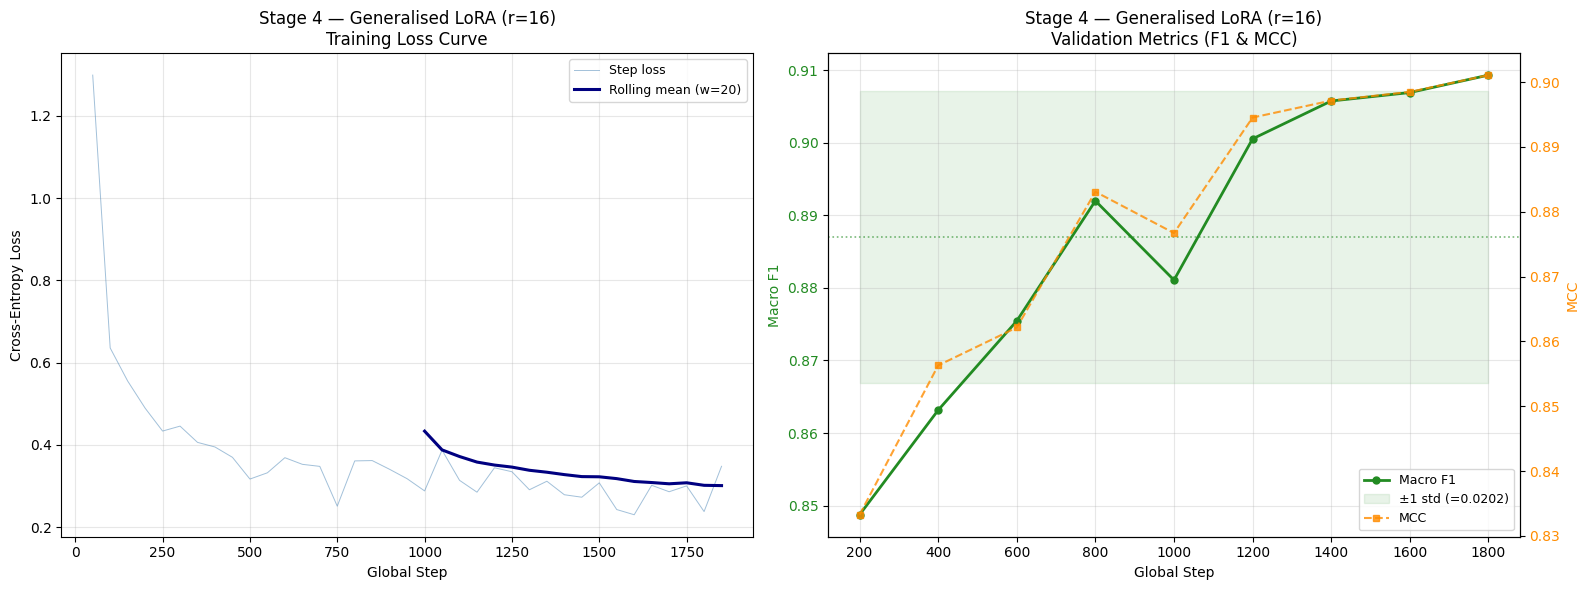


[6] Computing effective rank (Wf = W + W@(UV) + A@B)...
  ℹ 112 layers skipped during eff. rank computation
  ⚠ No GeneralisedLoRALayer found — check model structure
   Avg eff. rank Wf : 0.00  ← full adapted weight
   Avg eff. rank UV : 16.00  (mult. adapter, reference)
   Avg eff. rank AB : 16.00  (add. adapter, reference)
   Layers measured  : 0
   Stage 2 ref (r=16) : 2030.73  | Stage 3 ref (r=16) : 2030.39

[7] Evaluating on held-out test set (25%)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r16
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9091
  Macro F1          : 0.8981  ← PRIMARY METRIC
  Weighted F1       : 0.9095
  Balanced Accuracy : 0.8989
  MCC               : 0.8907  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7618    0.7346    0.7479      1424
             gender    

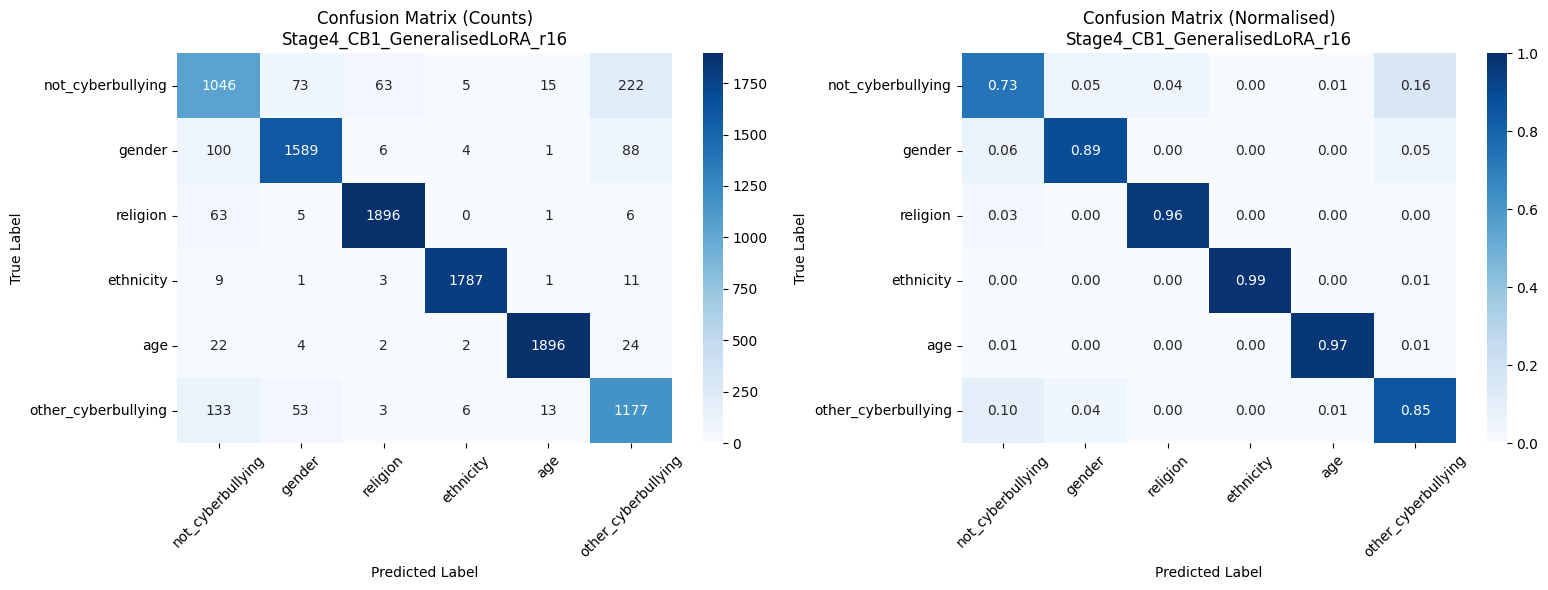


✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Llama3B/GeneralisedLoRA_r16/GeneralisedLoRA_r16_results.csv

═════════════════════════════════════════════════════════════════
  STAGE 4 RESULTS — Generalised LoRA (r=16)
  Formula : Wf = W(I + UV) + AB
  Model   : meta-llama/Llama-3.2-3B-Instruct
═════════════════════════════════════════════════════════════════
  Macro F1           : 0.8981   ← PRIMARY METRIC
  MCC                : 0.8907
  Accuracy           : 0.9091
  Balanced Accuracy  : 0.8989
  Trainable params   : 29,378,560
  Eff. rank (Wf)     : 0.00  ← Stage 2: 2030.73 | Stage 3: 2030.39
  Eff. rank (UV)     : 16.00  (mult. adapter, reference)
  Eff. rank (AB)     : 16.00  (add. adapter, reference)
  Stability score    : 0.245826
  Training time      : 3217s (0.89 hrs)
═════════════════════════════════════════════════════════════════

  Stage 2 Llama-3B r=16 : F1=0.8938 | MCC=0.8851 | Eff.Rank=2030.73
  Stage 3 Llama-3B r=16 : F1=0.8918 | MCC=0.8831 | Eff.R

In [12]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 12: Generalised LoRA CB1 — Llama-3.2-3B — r=16 (default)
# ════════════════════════════════════════════════════════════════════════════

results_r16 = run_generalised_lora(
    train_df  = train_df,
    val_df    = val_df,
    test_df   = test_df,
    lora_rank = 16,
    run_label = 'GeneralisedLoRA_r16'
)

print('\n' + '═'*65)
print('  STAGE 4 RESULTS — Generalised LoRA (r=16)')
print('  Formula : Wf = W(I + UV) + AB')
print('  Model   : meta-llama/Llama-3.2-3B-Instruct')
print('═'*65)
print(f'  Macro F1           : {results_r16["macro_f1"]:.4f}   ← PRIMARY METRIC')
print(f'  MCC                : {results_r16["mcc"]:.4f}')
print(f'  Accuracy           : {results_r16["accuracy"]:.4f}')
print(f'  Balanced Accuracy  : {results_r16["balanced_accuracy"]:.4f}')
print(f'  Trainable params   : {results_r16["trainable_params"]:,}')
print(f'  Eff. rank (Wf)     : {results_r16["avg_eff_rank_Wf"]:.2f}  ← Stage 2: 2030.73 | Stage 3: 2030.39')
print(f'  Eff. rank (UV)     : {results_r16["avg_eff_rank_UV"]:.2f}  (mult. adapter, reference)')
print(f'  Eff. rank (AB)     : {results_r16["avg_eff_rank_AB"]:.2f}  (add. adapter, reference)')
print(f'  Stability score    : {results_r16["stability_score"]}')
print(f'  Training time      : {results_r16["train_runtime_s"]:.0f}s ({results_r16["train_runtime_s"]/3600:.2f} hrs)')
print('═'*65)
print()
print('  Stage 2 Llama-3B r=16 : F1=0.8938 | MCC=0.8851 | Eff.Rank=2030.73')
print('  Stage 3 Llama-3B r=16 : F1=0.8918 | MCC=0.8831 | Eff.Rank=2030.39')
print('  Δ vs Stage 2           :', f'{results_r16["macro_f1"] - 0.8938:+.4f}')
print('  Δ vs Stage 3           :', f'{results_r16["macro_f1"] - 0.8918:+.4f}')
print()
print('  → results_r16 stored. Step 13 sweeps r ∈ {4, 8, 32} and merges this result.')


---
## Step 13: Rank Sweep Ablation — r ∈ {4, 8, 32}

**Purpose**: Run Generalised LoRA for r ∈ {4, 8, 32}. **r=16 is merged from Step 12 — NOT re-trained.**

After the sweep, the complete 4-rank summary table is printed with all three eff. rank columns (Wf, UV, AB).

**Research questions answered here:**
1. Does `eff_rank(Wf)` remain constant across r ∈ {4, 8, 16, 32}?  
   - If constant → W dominates; both adapters too small to shift rank  
   - If varies → AB has measurably expanded rank beyond rank(W) — Proposition 2 demonstrated  
2. Does Stage 4 beat Stage 2 (best: F1=0.9010) across all ranks?  
3. Does the Mistral r=16 instability pattern (Stage 3 F1=0.7616) carry to other models? Watch here for Llama.



───────────────────────────────────────────────────────
  Rank sweep: r=4
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r4
  Model   : meta-llama/Llama-3.2-3B-Instruct
  Rank r  : 4  |  Alpha: 4  |  Scaling: 1.0
  Formula : Wf = W(I + UV) + AB   [both paths active]
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 128,000
[2] Mapping labels and preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

   PEFT shell registered — model flagged as PEFT model (Trainer check satisfied)
[4] Injecting GeneralisedLoRALayer (Wf = W(I+UV) + AB)...
  ✓ Replaced 112 PEFT LoraLayers with GeneralisedLoRALayer
   Trainable params : 7,358,464
   Total params     : 1,810,840,576
   Trainable %      : 0.4064%
Class weights (inverse-frequency, normalised):
  [0] not_cyberbullying         1.1500
  [1] gender                    0.9458
  [2] religion                  0.9007
  [3] ethnicity                 0.8859
  [4] age                       0.8985
  [5] other_cyberbullying       1.2190

[5] Training (Wf = W(I+UV) + AB, r=4)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.492100,0.410559,0.862466,0.848738,0.835048
400,0.418600,0.399771,0.875492,0.859382,0.851103
600,0.379400,0.359637,0.881854,0.872240,0.858989
800,0.354900,0.341634,0.896092,0.884916,0.875364
1000,0.313700,0.324394,0.901242,0.888992,0.881962
1200,0.368700,0.302392,0.906089,0.895570,0.887261
1400,0.298600,0.290244,0.903968,0.895321,0.884958
1600,0.260800,0.288937,0.910633,0.901797,0.892595
1800,0.265400,0.276960,0.909421,0.901330,0.891375


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

   Training time: 3054s (0.85 hrs)
✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Llama3B/GeneralisedLoRA_r4/stability_GeneralisedLoRA_r4.png


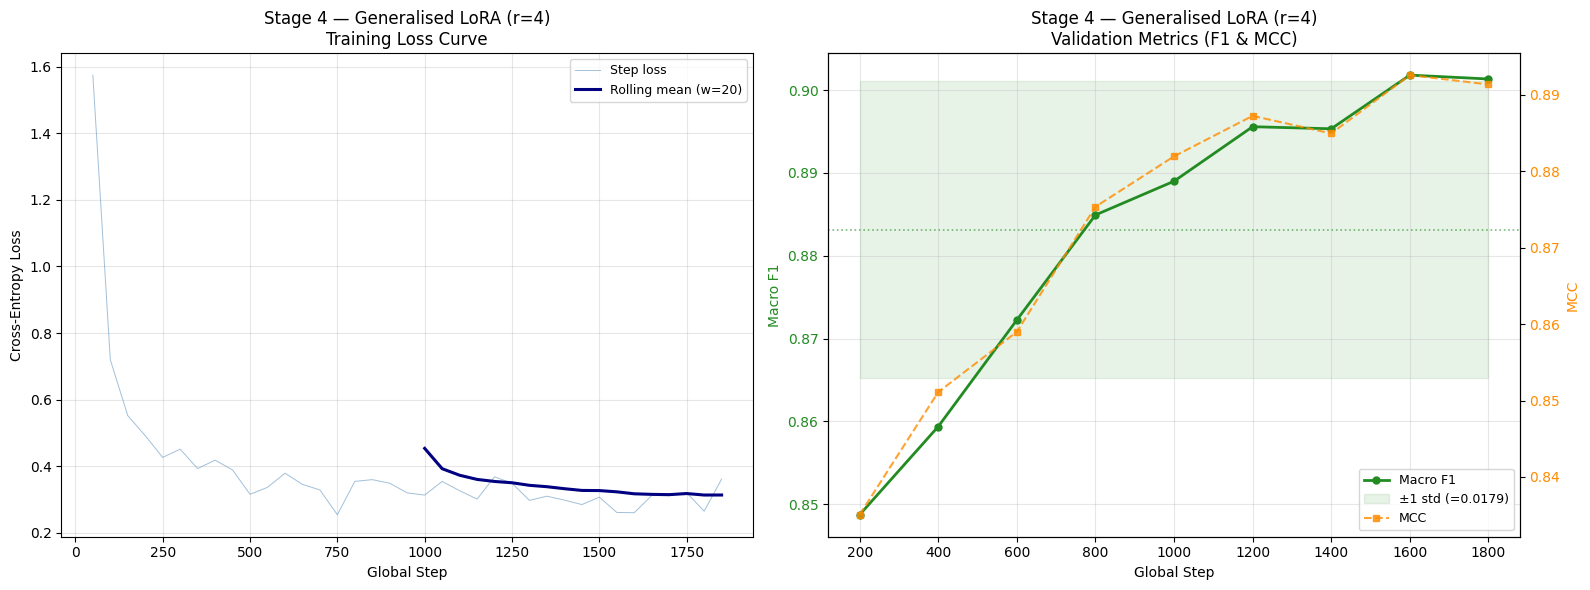


[6] Computing effective rank (Wf = W + W@(UV) + A@B)...
  ℹ 112 layers skipped during eff. rank computation
  ⚠ No GeneralisedLoRALayer found — check model structure
   Avg eff. rank Wf : 0.00  ← full adapted weight
   Avg eff. rank UV : 4.00  (mult. adapter, reference)
   Avg eff. rank AB : 4.00  (add. adapter, reference)
   Layers measured  : 0
   Stage 2 ref (r=16) : 2030.73  | Stage 3 ref (r=16) : 2030.39

[7] Evaluating on held-out test set (25%)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r4
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9010
  Macro F1          : 0.8896  ← PRIMARY METRIC
  Weighted F1       : 0.9017
  Balanced Accuracy : 0.8905
  MCC               : 0.8810  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7326    0.7233    0.7279      1424
             gender     0.

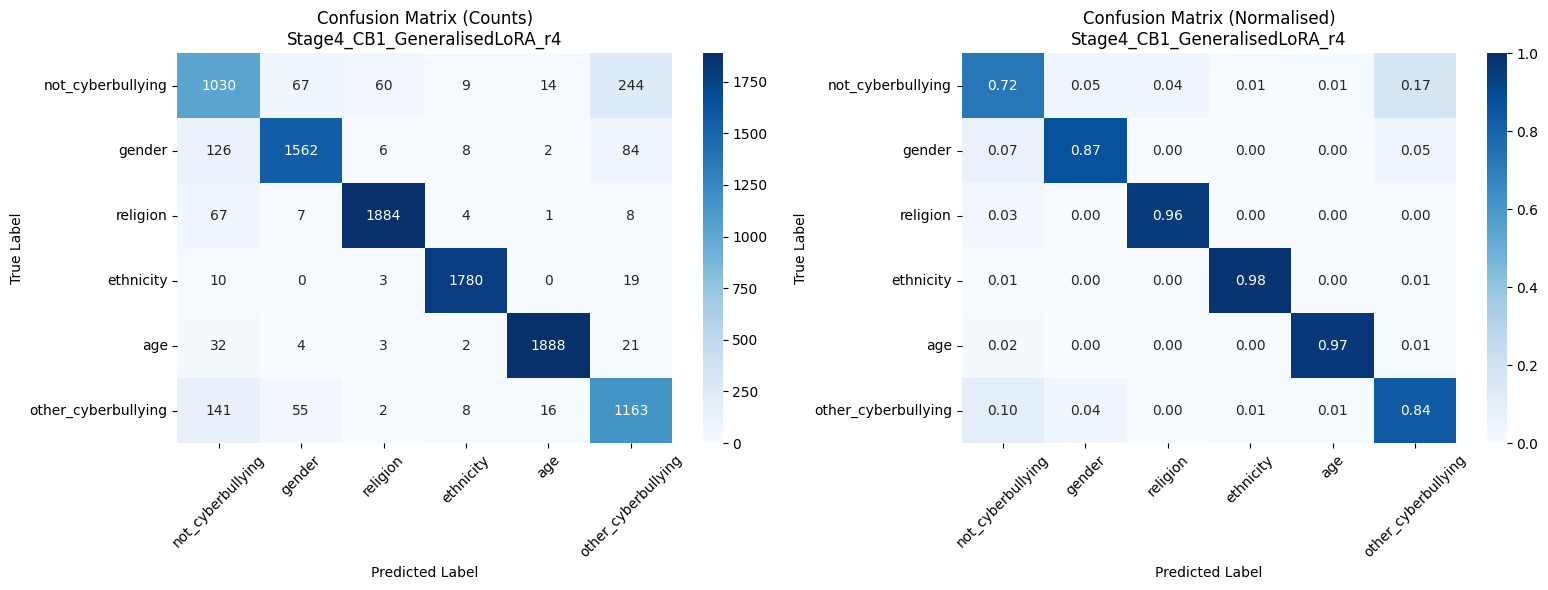


✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Llama3B/GeneralisedLoRA_r4/GeneralisedLoRA_r4_results.csv

───────────────────────────────────────────────────────
  Rank sweep: r=8
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r8
  Model   : meta-llama/Llama-3.2-3B-Instruct
  Rank r  : 8  |  Alpha: 8  |  Scaling: 1.0
  Formula : Wf = W(I + UV) + AB   [both paths active]
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 128,000
[2] Mapping labels and preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

   PEFT shell registered — model flagged as PEFT model (Trainer check satisfied)
[4] Injecting GeneralisedLoRALayer (Wf = W(I+UV) + AB)...
  ✓ Replaced 112 PEFT LoraLayers with GeneralisedLoRALayer
   Trainable params : 14,698,496
   Total params     : 1,818,180,608
   Trainable %      : 0.8084%
Class weights (inverse-frequency, normalised):
  [0] not_cyberbullying         1.1500
  [1] gender                    0.9458
  [2] religion                  0.9007
  [3] ethnicity                 0.8859
  [4] age                       0.8985
  [5] other_cyberbullying       1.2190

[5] Training (Wf = W(I+UV) + AB, r=8)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.490100,0.382579,0.870342,0.859192,0.844597
400,0.425800,0.376939,0.877613,0.862009,0.853421
600,0.363100,0.372024,0.875492,0.867114,0.851754
800,0.343800,0.341134,0.902454,0.891773,0.882847
1000,0.294000,0.326712,0.899727,0.886997,0.880553
1200,0.362100,0.297587,0.909421,0.898489,0.891423
1400,0.289000,0.281962,0.906089,0.897032,0.887469
1600,0.247000,0.282841,0.910330,0.901314,0.892304
1800,0.243900,0.269246,0.909724,0.900904,0.891742


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

   Training time: 3088s (0.86 hrs)
✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Llama3B/GeneralisedLoRA_r8/stability_GeneralisedLoRA_r8.png


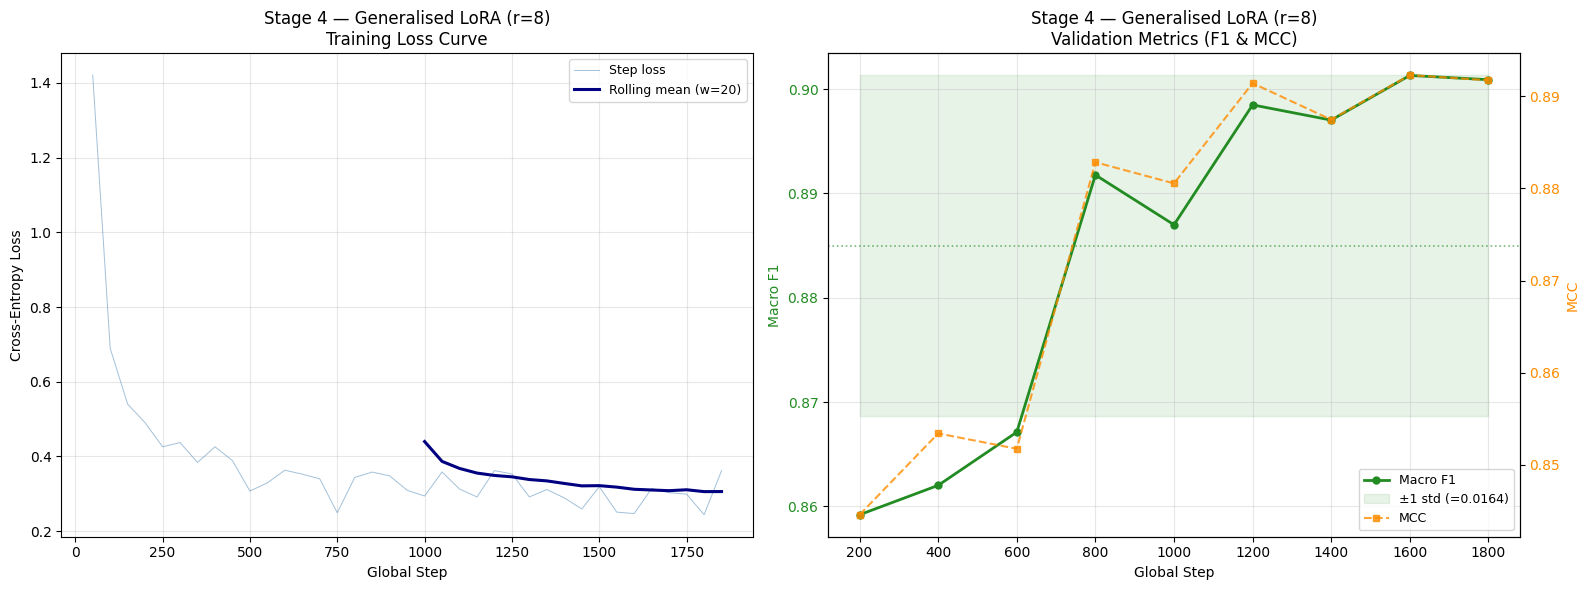


[6] Computing effective rank (Wf = W + W@(UV) + A@B)...
  ℹ 112 layers skipped during eff. rank computation
  ⚠ No GeneralisedLoRALayer found — check model structure
   Avg eff. rank Wf : 0.00  ← full adapted weight
   Avg eff. rank UV : 8.00  (mult. adapter, reference)
   Avg eff. rank AB : 8.00  (add. adapter, reference)
   Layers measured  : 0
   Stage 2 ref (r=16) : 2030.73  | Stage 3 ref (r=16) : 2030.39

[7] Evaluating on held-out test set (25%)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r8
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9056
  Macro F1          : 0.8945  ← PRIMARY METRIC
  Weighted F1       : 0.9062
  Balanced Accuracy : 0.8954
  MCC               : 0.8865  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7509    0.7303    0.7405      1424
             gender     0.

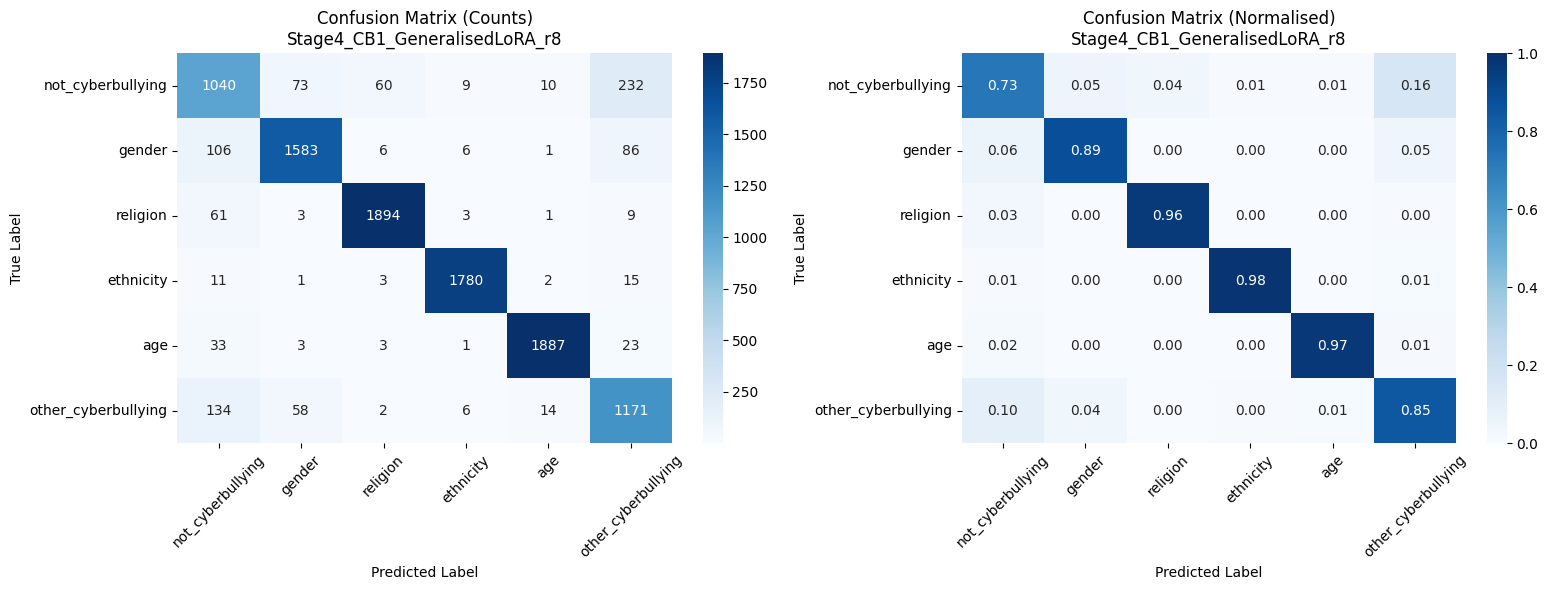


✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Llama3B/GeneralisedLoRA_r8/GeneralisedLoRA_r8_results.csv

───────────────────────────────────────────────────────
  Rank sweep: r=32
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r32
  Model   : meta-llama/Llama-3.2-3B-Instruct
  Rank r  : 32  |  Alpha: 32  |  Scaling: 1.0
  Formula : Wf = W(I + UV) + AB   [both paths active]
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 128,000
[2] Mapping labels and preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

   Trainable params : 58,738,688
   Total params     : 1,862,220,800
   Trainable %      : 3.1542%
Class weights (inverse-frequency, normalised):
  [0] not_cyberbullying         1.1500
  [1] gender                    0.9458
  [2] religion                  0.9007
  [3] ethnicity                 0.8859
  [4] age                       0.8985
  [5] other_cyberbullying       1.2190

[5] Training (Wf = W(I+UV) + AB, r=32)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.482100,0.459736,0.821266,0.804273,0.794166
400,0.431400,0.496211,0.866404,0.843437,0.842219
600,0.369600,0.360188,0.882460,0.872100,0.859684
800,0.341200,0.320295,0.902757,0.891938,0.883093
1000,0.296300,0.342889,0.896698,0.881154,0.877982
1200,0.344700,0.275599,0.912148,0.900488,0.894922
1400,0.276700,0.268984,0.906998,0.898544,0.888620
1600,0.233100,0.267711,0.914874,0.906781,0.897853
1800,0.239400,0.253587,0.917298,0.909274,0.900744


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

   Training time: 3407s (0.95 hrs)
✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Llama3B/GeneralisedLoRA_r32/stability_GeneralisedLoRA_r32.png


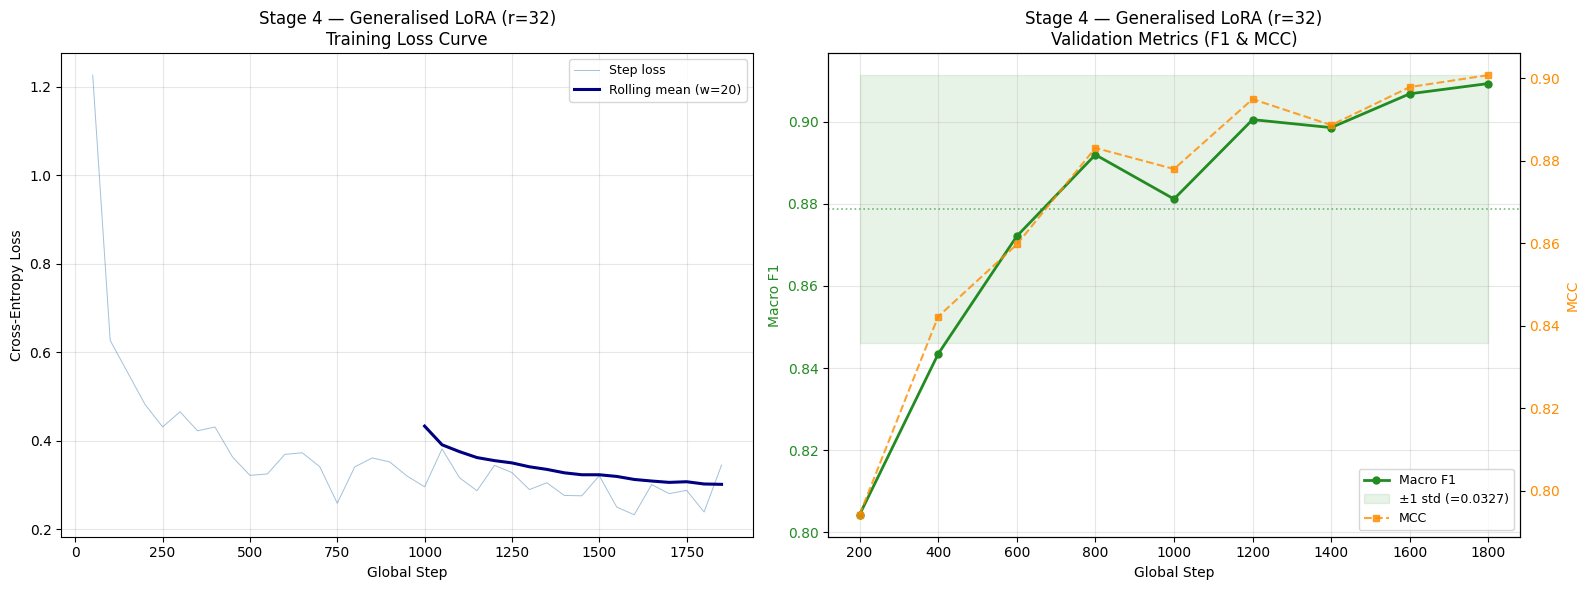


[6] Computing effective rank (Wf = W + W@(UV) + A@B)...
  ℹ 112 layers skipped during eff. rank computation
  ⚠ No GeneralisedLoRALayer found — check model structure
   Avg eff. rank Wf : 0.00  ← full adapted weight
   Avg eff. rank UV : 32.00  (mult. adapter, reference)
   Avg eff. rank AB : 32.00  (add. adapter, reference)
   Layers measured  : 0
   Stage 2 ref (r=16) : 2030.73  | Stage 3 ref (r=16) : 2030.39

[7] Evaluating on held-out test set (25%)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r32
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9078
  Macro F1          : 0.8967  ← PRIMARY METRIC
  Weighted F1       : 0.9083
  Balanced Accuracy : 0.8973
  MCC               : 0.8891  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7489    0.7374    0.7431      1424
             gender    

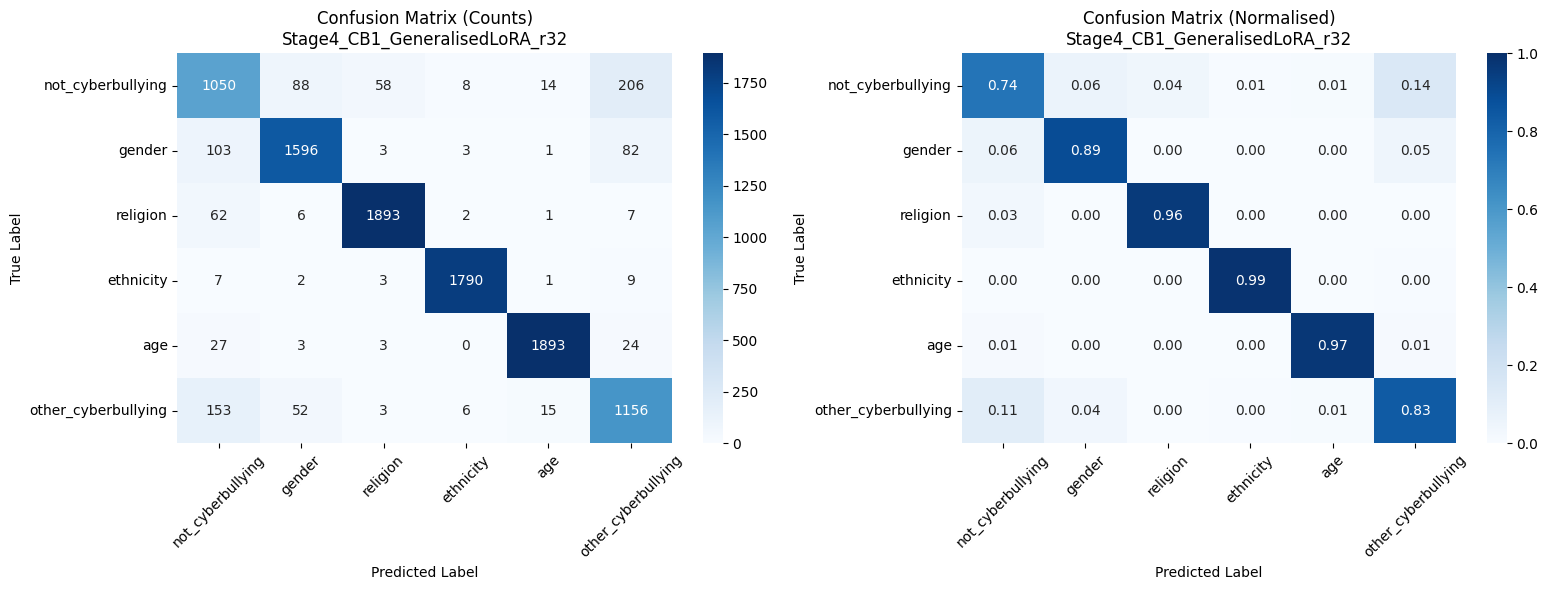


✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Llama3B/GeneralisedLoRA_r32/GeneralisedLoRA_r32_results.csv

════════════════════════════════════════════════════════════════════════════════════════════════════
STAGE 4a CB1 LLAMA-3B — 4-RANK SUMMARY TABLE
Formula: Wf = W(I + UV) + AB
════════════════════════════════════════════════════════════════════════════════════════════════════
   r |    Trainable |  Macro F1 |     MCC | Eff.Rank Wf | Eff.Rank UV | Eff.Rank AB |  Time(h) | Trend
────────────────────────────────────────────────────────────────────────────────────────────────────
   4 |    7,358,464 |    0.8896 |  0.8810 |        0.00 |        4.00 |        4.00 |     0.85 | 
   8 |   14,698,496 |    0.8945 |  0.8865 |        0.00 |        8.00 |        8.00 |     0.86 | ↑
  16 |   29,378,560 |    0.8981 |  0.8907 |        0.00 |       16.00 |       16.00 |     0.89 | ↑ ★
  32 |   58,738,688 |    0.8967 |  0.8891 |        0.00 |       32.00 |       32.00 |     0

In [13]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 13: Rank Sweep — r ∈ {4, 8, 32}
# r=16 NOT repeated — merged from Step 12 results_r16
# ════════════════════════════════════════════════════════════════════════════

all_rank_results = {}
all_rank_results[16] = results_r16   # Merge r=16 from Step 12

for rank in RANK_SWEEP:   # [4, 8, 32]
    print(f'\n{"─"*55}')
    print(f'  Rank sweep: r={rank}')
    print(f'{"─"*55}')
    result = run_generalised_lora(
        train_df  = train_df,
        val_df    = val_df,
        test_df   = test_df,
        lora_rank = rank,
        run_label = f'GeneralisedLoRA_r{rank}'
    )
    all_rank_results[rank] = result

# ── 4-rank summary table ──────────────────────────────────────────────────────
print(f'\n{"═"*100}')
print('STAGE 4a CB1 LLAMA-3B — 4-RANK SUMMARY TABLE')
print('Formula: Wf = W(I + UV) + AB')
print(f'{"═"*100}')
print(f'{"r":>4} | {"Trainable":>12} | {"Macro F1":>9} | {"MCC":>7} | '
      f'{"Eff.Rank Wf":>11} | {"Eff.Rank UV":>11} | {"Eff.Rank AB":>11} | {"Time(h)":>8} | Trend')
print(f'{"─"*100}')

sorted_ranks = sorted(all_rank_results.keys())
prev_f1 = None
for r in sorted_ranks:
    res  = all_rank_results[r]
    trend = ''
    if prev_f1 is not None:
        trend = '↑' if res['macro_f1'] > prev_f1 else ('↓' if res['macro_f1'] < prev_f1 else '→')
    best_mark = ' ★' if res['macro_f1'] == max(v['macro_f1'] for v in all_rank_results.values()) else ''
    print(
        f'{r:>4} | {res["trainable_params"]:>12,} | '
        f'{res["macro_f1"]:>9.4f} | {res["mcc"]:>7.4f} | '
        f'{res["avg_eff_rank_Wf"]:>11.2f} | {res["avg_eff_rank_UV"]:>11.2f} | '
        f'{res["avg_eff_rank_AB"]:>11.2f} | '
        f'{res["train_runtime_s"]/3600:>8.2f} | {trend}{best_mark}'
    )
    prev_f1 = res['macro_f1']

# ── Cross-stage reference rows ────────────────────────────────────────────────
print(f'\n  Stage 2 reference (Llama-3B Standard LoRA):')
print(f'  r=4: F1=0.8881 | r=8: F1=0.8902 | r=16: F1=0.8938 | r=32: F1=0.8958 (best)')
print(f'  Stage 3 reference (Llama-3B Multiplicative LoRA):')
print(f'  r=4: F1=0.8887 | r=8: F1=0.8901 | r=16: F1=0.8918 | r=32: F1=0.8939 (best)')

# ── Eff. rank constancy analysis ──────────────────────────────────────────────
print(f'\n{"═"*60}')
print('EFFECTIVE RANK CONSTANCY ANALYSIS — Stage 4')
print(f'{"═"*60}')
eff_ranks_Wf = [all_rank_results[r]['avg_eff_rank_Wf'] for r in sorted_ranks]
eff_range_Wf = max(eff_ranks_Wf) - min(eff_ranks_Wf)
ref_rank_W   = 2030.73  # Stage 2 eff. rank = rank(W) for Llama-3B
print(f'Eff. rank Wf values : {[f"{v:.2f}" for v in eff_ranks_Wf]}')
print(f'Range               : {eff_range_Wf:.2f}')
print(f'Reference rank(W)   : {ref_rank_W:.2f}  (from Stage 2/3)')
if eff_range_Wf < 1.0:
    print('✓ CONSTANT — W dominates; both adapters too small to shift rank.')
    print('  Propositions 1 & 2 consistent: rank(W(I+UV)+AB) ≈ rank(W).')
else:
    print('⚠ VARIES — one or both adapters affect rank dynamics.')
    if max(eff_ranks_Wf) > ref_rank_W + 0.5:
        print('  ★ Eff.Rank(Wf) > rank(W) — AB has added new singular directions.')
        print('    Proposition 2 (Weyl bound) demonstrated empirically. Report in paper.')
    else:
        print('  Multiplicative component reduces rank; report novel finding in paper.')

# ── Save final CSV ─────────────────────────────────────────────────────────────
summary_rows = []
for r in sorted_ranks:
    res = all_rank_results[r]
    summary_rows.append({
        'model': 'Llama-3.2-3B', 'stage': '4a', 'formula': 'Wf=W(I+UV)+AB',
        'dataset': 'CB1', 'rank': r,
        'trainable_params':  res['trainable_params'],
        'macro_f1':          res['macro_f1'],
        'mcc':               res['mcc'],
        'accuracy':          res['accuracy'],
        'balanced_accuracy': res['balanced_accuracy'],
        'avg_eff_rank_Wf':   res['avg_eff_rank_Wf'],
        'avg_eff_rank_UV':   res['avg_eff_rank_UV'],
        'avg_eff_rank_AB':   res['avg_eff_rank_AB'],
        'stability_score':   res['stability_score'],
        'train_runtime_s':   res['train_runtime_s'],
    })

summary_df   = pd.DataFrame(summary_rows)
summary_path = os.path.join(OUTPUT_DIR, 'stage4a_cb1_llama3b_rank_sweep_FINAL.csv')
summary_df.to_csv(summary_path, index=False)
print(f'\n✓ Final rank sweep results saved → {summary_path}')


---
## Step 14: Cross-Stage Stability Comparison + Final Summary

**Purpose**: Complete the 3-stage stability comparison and print the final Stage 4 summary for the paper.

**Step 14A** — Cross-stage stability plot (3 stages × 4 metrics): now fully populated.  
Fill in the Stage 2 and Stage 3 stability reports from those notebooks and uncomment.

**Step 14B** — Final Stage 4 summary printout for paper results tables.

**Stage 2 stability (r=16)**: loss_cv=0.825 | loss_std=0.343 | val_f1_std=0.0247 | score=0.4249  
**Stage 3 stability (r=16)**: loss_cv=0.885 | loss_std=0.346 | val_f1_std=0.0295 | score=0.4574


Stage 4 stability report (r=16):
  loss_cv_overall  : 0.471493963835416
  loss_std_overall : 0.17522372296537533
  val_f1_std       : 0.020158347691012383
  val_mcc_std      : 0.02197234867669628
  stability_score  : 0.245826
✓ Cross-stage stability plot saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Llama3B/cross_stage_stability_llama3b.png


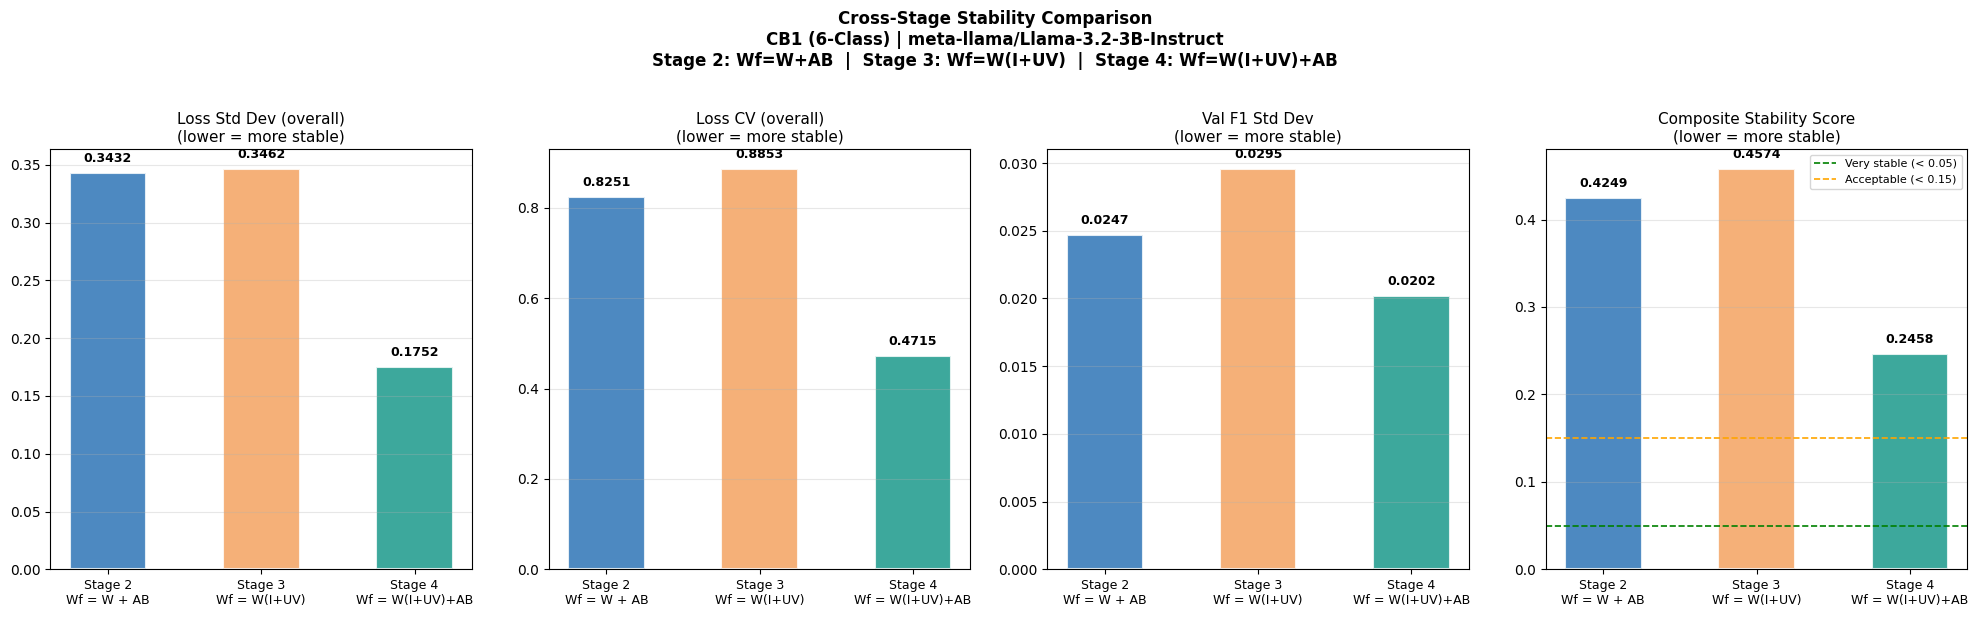


══════════════════════════════════════════════════════════════════════
  STAGE 4a COMPLETE — GENERALISED LoRA
  Formula  : Wf = W(I + UV) + AB
  Model    : meta-llama/Llama-3.2-3B-Instruct
  Dataset  : CB1 — 6-Class Cyberbullying Detection
  Split    : 75/25 stratified (protocol-compliant)
══════════════════════════════════════════════════════════════════════

── BEST RESULT (r=16) ──
  Macro F1           : 0.8981   ← PRIMARY METRIC
  MCC                : 0.8907
  Accuracy           : 0.9091
  Balanced Accuracy  : 0.8989
  Trainable params   : 29,378,560
  Eff. rank (Wf)     : 0.00   ← S2: 2030.73 | S3: 2030.39
  Eff. rank (UV)     : 16.00  (mult. adapter, reference)
  Eff. rank (AB)     : 16.00  (add. adapter, reference)
  Training time      : 3217s (0.89 hrs)

── CROSS-STAGE COMPARISON (Llama-3B, best rank each stage) ──
  Stage 2 (r=32) : F1=0.8958 | MCC=0.8874 | Eff.Rank=2030.76
  Stage 3 (r=32) : F1=0.8939 | MCC=0.8857 | Eff.Rank=2030.17
  Stage 4 (r=16) : F1=0.8981 | MCC=0.8907 

In [14]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 14A: CROSS-STAGE STABILITY COMPARISON — all 3 stages
# Uncomment and fill in Stage 2 and Stage 3 stability reports after confirming results
# ════════════════════════════════════════════════════════════════════════════

# Stage 2 stability report (r=16) — paste from Stage 2 notebook Step 14:
S2_STABILITY = {
    'loss_cv_overall':  0.8250890329112768,
    'loss_std_overall': 0.34319385762043336,
    'val_f1_std':       0.024721563075468946,
    'val_mcc_std':      0.024702983008093447,
    'stability_score':  0.424905,
}

# Stage 3 stability report (r=16) — paste from Stage 3 notebook Step 14:
S3_STABILITY = {
    'loss_cv_overall':  0.8852928592215558,
    'loss_std_overall': 0.34620629448242835,
    'val_f1_std':       0.029538375057606814,
    'val_mcc_std':      0.02939973459905556,
    'stability_score':  0.457416,
}

# Stage 4 stability (r=16) — from this run:
S4_STABILITY = results_r16['stability_cb'].get_stability_report()

print('Stage 4 stability report (r=16):')
print(f'  loss_cv_overall  : {S4_STABILITY.get("loss_cv_overall",  "N/A")}')
print(f'  loss_std_overall : {S4_STABILITY.get("loss_std_overall", "N/A")}')
print(f'  val_f1_std       : {S4_STABILITY.get("val_f1_std",       "N/A")}')
print(f'  val_mcc_std      : {S4_STABILITY.get("val_mcc_std",      "N/A")}')
print(f'  stability_score  : {S4_STABILITY.get("stability_score",  "N/A")}')

# ── Cross-stage plot (uncomment after confirming all results) ─────────────────
plot_cross_stage_stability(
    stage_reports={
        'Stage 2\nWf = W + AB':        S2_STABILITY,
        'Stage 3\nWf = W(I+UV)':       S3_STABILITY,
        'Stage 4\nWf = W(I+UV)+AB':    S4_STABILITY,
    },
    save_path=os.path.join(OUTPUT_DIR, 'cross_stage_stability_llama3b.png')
)

# ════════════════════════════════════════════════════════════════════════════
# STEP 14B: FINAL STAGE 4 SUMMARY — for paper results tables
# ════════════════════════════════════════════════════════════════════════════
print('\n' + '═'*70)
print('  STAGE 4a COMPLETE — GENERALISED LoRA')
print('  Formula  : Wf = W(I + UV) + AB')
print('  Model    : meta-llama/Llama-3.2-3B-Instruct')
print('  Dataset  : CB1 — 6-Class Cyberbullying Detection')
print('  Split    : 75/25 stratified (protocol-compliant)')
print('═'*70)

best_r   = max(all_rank_results, key=lambda r: all_rank_results[r]['macro_f1'])
best_res = all_rank_results[best_r]
print(f'\n── BEST RESULT (r={best_r}) ──')
print(f'  Macro F1           : {best_res["macro_f1"]:.4f}   ← PRIMARY METRIC')
print(f'  MCC                : {best_res["mcc"]:.4f}')
print(f'  Accuracy           : {best_res["accuracy"]:.4f}')
print(f'  Balanced Accuracy  : {best_res["balanced_accuracy"]:.4f}')
print(f'  Trainable params   : {best_res["trainable_params"]:,}')
print(f'  Eff. rank (Wf)     : {best_res["avg_eff_rank_Wf"]:.2f}   ← S2: 2030.73 | S3: 2030.39')
print(f'  Eff. rank (UV)     : {best_res["avg_eff_rank_UV"]:.2f}  (mult. adapter, reference)')
print(f'  Eff. rank (AB)     : {best_res["avg_eff_rank_AB"]:.2f}  (add. adapter, reference)')
print(f'  Training time      : {best_res["train_runtime_s"]:.0f}s ({best_res["train_runtime_s"]/3600:.2f} hrs)')
print()
print('── CROSS-STAGE COMPARISON (Llama-3B, best rank each stage) ──')
print('  Stage 2 (r=32) : F1=0.8958 | MCC=0.8874 | Eff.Rank=2030.76')
print('  Stage 3 (r=32) : F1=0.8939 | MCC=0.8857 | Eff.Rank=2030.17')
print(f'  Stage 4 (r={best_r:>2}) : F1={best_res["macro_f1"]:.4f} | MCC={best_res["mcc"]:.4f} | Eff.Rank={best_res["avg_eff_rank_Wf"]:.2f}')
print()
print('── OVERALL TARGETS ──')
print('  Stage 2 best overall (Gemma-2-9B r=32): F1=0.9010 | MCC=0.8936')
print('  Stage 3 best overall (Gemma-3-27B r=16): F1=0.8988 | MCC=0.8911')
print(f'  Stage 4 Llama-3B (this notebook)       : F1={best_res["macro_f1"]:.4f} | MCC={best_res["mcc"]:.4f}')
if best_res["macro_f1"] > 0.9010:
    print('  ★ STAGE 4 LLAMA-3B BEATS OVERALL STAGE 2 CHAMPION (0.9010)')
elif best_res["macro_f1"] > 0.8958:
    print('  ✓ Stage 4 Llama-3B beats Stage 2 Llama-3B best (0.8958)')
else:
    print('  → Stage 4 Llama-3B below Stage 2 Llama-3B best — check larger models.')
print()
print('  → Stage 4 CB1 complete for Llama-3.2-3B.')
print('  → Next: Stage 4 CB1 Mistral-7B  (watch r=16 instability)')
